# CLoS & JAT Scoring Pipeline

Computes link-level Cycling Level of Service (CLoS) and Junction Assessment
Tool (JAT) scores for the West Midlands metropolitan county cycling network,
following LTN 1/20 Appendix A criteria.

## Notebook Structure

| Section | Content |
|---------|---------|
| 0 | Setup and constants |
| 1 | Study area boundary |
| 2 | Data loading (OS NGD Road Links, Cycle Lanes, Highway Dedication) |
| 3 | Network preparation (cycleable links, facility classification) |
| 4 | Speed and AADT data |
| 5 | **Safety criteria** (S10 Speed, S11 Volume, S12 Segregation, S15 Kerbside) |
| 6 | Safety aggregate |
| 7 | **Attractiveness criteria** (A3 Density, A19 Width, A21 Lighting, A22 Isolation, A25 Parking) |
| 8 | Attractiveness aggregate |
| 9 | **JAT** (Junction Assessment Tool) |
| 10 | **Overall CLoS aggregate** |
| 11 | Visualisation |
| 12 | Export (network GeoPackage, POI GeoJSON, cycle parking GeoJSON) |

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
from shapely import wkt
from shapely.ops import unary_union
from scipy.spatial import cKDTree

ox.settings.timeout = 600

# Project paths
DATA_DIR = Path('../Data/Raw')
OUTPUT_DIR = Path('../Data/Cleaned')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Coordinate reference systems
CRS_WGS84 = 'EPSG:4326'
CRS_BNG = 'EPSG:27700'

pd.set_option('display.max_columns', None)
print(f"Working directory: {os.getcwd()}")


Working directory: /Users/pippin/github/ltn1-20-assessment-tool-wm/Code


---
## 1. Study Area Boundary

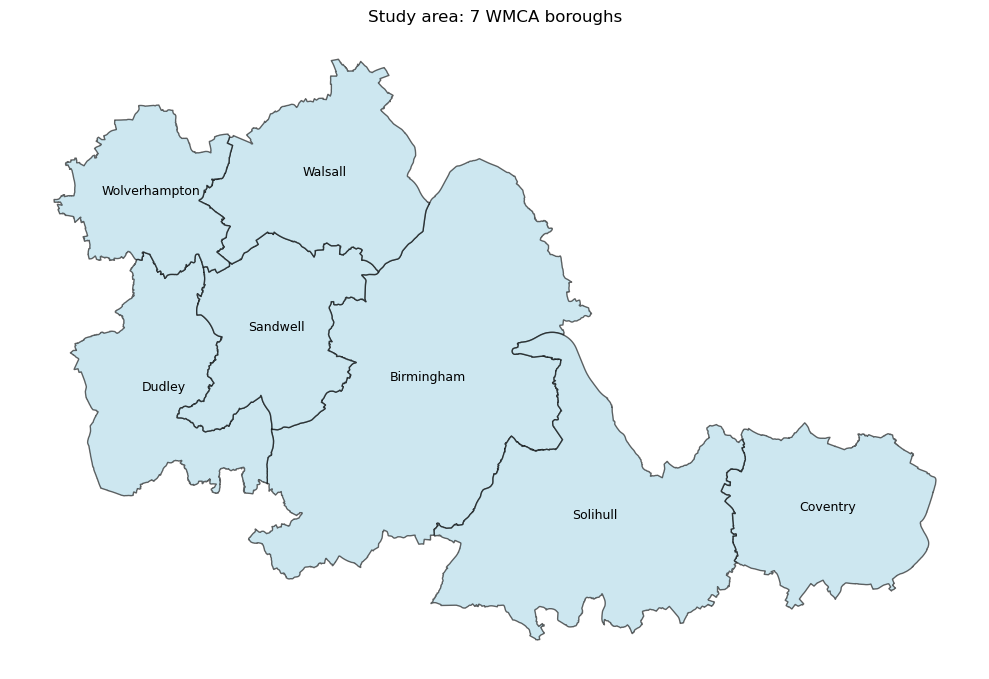


Total study area: 901.7 km2


In [2]:
STUDY_AREA_BOROUGHS = [
    'Birmingham',
    'Coventry',
    'Dudley',
    'Sandwell',
    'Solihull',
    'Walsall',
    'Wolverhampton',
]

raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].copy()
study_area = study_area.to_crs(CRS_BNG)

fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.6)
study_area.apply(lambda r: ax.annotate(
    text=r['LAD25NM'],
    xy=(r.geometry.centroid.x, r.geometry.centroid.y),
    ha='center', fontsize=9
), axis=1)
ax.set_title(f'Study area: {len(STUDY_AREA_BOROUGHS)} WMCA boroughs')
ax.set_axis_off()
plt.tight_layout()
plt.show()

total_area_km2 = study_area.geometry.area.sum() / 1e6
print(f"\nTotal study area: {total_area_km2:.1f} km2")


---
## 2. Data Loading

In [3]:
# --- 2a. OS NGD Road Links ---
os_road_network = gpd.read_file(DATA_DIR / "os_datasets/trn_ntwk_roadlink.zip")
os_road_network["geometry"] = os_road_network["geometry"].apply(wkt.loads)
os_road_network = gpd.GeoDataFrame(os_road_network, geometry="geometry", crs=CRS_BNG)

print(f"Road links: {os_road_network.shape[0]:,} features, {os_road_network.shape[1]} columns")
print(f"\nRoad type distribution:")
print(os_road_network['roadclassification'].value_counts())

Road links: 217,416 features, 78 columns

Road type distribution:
roadclassification
Unclassified             126569
Unknown                   37297
A Road                    19436
Not Classified            12402
B Road                    10732
Classified Unnumbered     10277
Motorway                    703
Name: count, dtype: int64


In [4]:
# --- 2b. OS NGD Cycle Lanes ---
os_cycle_lane = gpd.read_file(DATA_DIR / "os_datasets/trn_ntwk_cyclelane.zip")
os_cycle_lane["geometry"] = os_cycle_lane["geometry"].apply(wkt.loads)
os_cycle_lane = gpd.GeoDataFrame(os_cycle_lane, geometry="geometry", crs=CRS_BNG)

print(f"Cycle lanes: {os_cycle_lane.shape[0]:,} features")
print(f"\nCycle lane type distribution:")
print(os_cycle_lane['description'].value_counts())

Cycle lanes: 9,703 features

Cycle lane type distribution:
description
Unsegregated Shared-Use Cycle Facility    3520
Advisory Cycle Lane On Road               2604
Segregated Shared-Use Cycle Track         2005
Fully Segregated Cycle Track               836
Mandatory Cycle Lane On Road               456
Lightly Segregated Cycle Lane On Road      162
Stepped Cycle Track Along Road             111
Unknown Type Of Cycle Track Or Lane          9
Name: count, dtype: int64


In [5]:
# --- 2c. Highway Dedication ---
zip_path = DATA_DIR / "os_datasets/trn_rami_highwaydedication.zip"
with zipfile.ZipFile(zip_path) as z:
    hd = pd.read_csv(io.BytesIO(z.read("trn_rami_highwaydedication.csv")))
    hd_ref = pd.read_csv(io.BytesIO(z.read("trn_rami_highwaydedication_hwydedntwkref.csv")))

print(f"Highway Dedication records: {hd.shape[0]:,}")
print(f"Network references: {hd_ref.shape[0]:,} ({hd_ref['networkreferenceid'].nunique():,} unique links)")

Highway Dedication records: 114,540
Network references: 346,617 (236,813 unique links)


---
## 3. Network Preparation

In [95]:
# --- 3a. Join Highway Dedication to Road Links ---
hd_merged = hd_ref.merge(
    hd[['osid', 'description']],
    left_on='highwaydedicationid',
    right_on='osid',
    how='left'
)
hd_lookup = (
    hd_merged[['networkreferenceid', 'description']]
    .drop_duplicates(subset='networkreferenceid')
    .rename(columns={'networkreferenceid': 'osid', 'description': 'highway_dedication'})
)
os_road_network = os_road_network.merge(hd_lookup, on='osid', how='left')

In [96]:
# --- 3b. Filter to Cycleable Road Links ---
cycleable_dedications = [
    'All Vehicles',
    'Cycle Track Or Cycle Way',
    'Bridleway',
    'Restricted Byway',
    'Byway Open To All Traffic',
]
non_cycleable_descriptions = [
    'Motorway', 'A Road Primary',
]

cycleable_mask = (
    os_road_network['highway_dedication'].isin(cycleable_dedications) &
    ~os_road_network['roadclassification'].isin(non_cycleable_descriptions)
)
cycleable_roads = os_road_network[cycleable_mask].copy()
print(f"Cycleable road links: {len(cycleable_roads):,} / {len(os_road_network):,}")

Cycleable road links: 178,863 / 217,416


In [97]:
# --- 3c. Join Cycle Lane (direction-aware) ---

# Step 1: Separate cycle lanes by direction relative to digitisation
cl_cols = ['linkid', 'description', 'cyclelaneinfo_modalwidth_m',
           'cyclelaneinfo_minimumwidth_m', 'cyclelaneinfo_direction', 'sideoflink']
cl = os_cycle_lane[cl_cols].copy()

# "Both Directions" → applies to BOTH forward and backward edges
# "In Direction"    → applies to forward edge ONLY

is_forward = cl['cyclelaneinfo_direction'].isin(['In Direction', 'Both Directions'])
is_backward = cl['cyclelaneinfo_direction'] == 'Both Directions'

# Step 2: Build one row per link with forward/backward attributes
cl_forward = (
    cl[is_forward]
    .rename(columns={
        'description': 'cl_type_fwd',
        'cyclelaneinfo_modalwidth_m': 'cl_modalwidth_fwd',
        'cyclelaneinfo_minimumwidth_m': 'cl_minwidth_fwd',
        'sideoflink': 'cl_side_fwd',
    })
    .drop(columns=['cyclelaneinfo_direction'])
    .rename(columns={'linkid': 'osid'})
)

cl_backward = (
    cl[is_backward]
    .rename(columns={
        'description': 'cl_type_bwd',
        'cyclelaneinfo_modalwidth_m': 'cl_modalwidth_bwd',
        'cyclelaneinfo_minimumwidth_m': 'cl_minwidth_bwd',
        'sideoflink': 'cl_side_bwd',
    })
    .drop(columns=['cyclelaneinfo_direction'])
    .rename(columns={'linkid': 'osid'})
)

# Handle edge case: multiple cycle lanes in same direction on same link
# Keep the one with greater modal width (better facility)
cl_forward = cl_forward.sort_values('cl_modalwidth_fwd', ascending=False).drop_duplicates('osid', keep='first')
cl_backward = cl_backward.sort_values('cl_modalwidth_bwd', ascending=False).drop_duplicates('osid', keep='first')

# Step 3: Two-stage left join — no row duplication
cycleable_roads_with_cl = (
    cycleable_roads
    .merge(cl_forward, on='osid', how='left')
    .merge(cl_backward, on='osid', how='left')
)

In [98]:
# --- 3d. Facility Classification (direction-aware) ---
os_to_facility = {
    'Fully Segregated Cycle Track':           'Fully Kerbed Cycle Track',
    'Unsegregated Shared-Use Cycle Facility': 'Shared Use',
    'Segregated Shared-Use Cycle Track':      'Shared Use',
    'Advisory Cycle Lane On Road':            'Advisory Cycle Lane',
    'Mandatory Cycle Lane On Road':           'Mandatory Cycle Lane',
    'Lightly Segregated Cycle Lane On Road':  'Light Segregation',
    'Stepped Cycle Track Along Road':         'Stepped Cycle Track',
    'Unknown Type Of Cycle Track Or Lane':    'Mixed Traffic',
}

cycleable_roads_with_cl['facility_type_fwd'] = (
    cycleable_roads_with_cl['cl_type_fwd']
    .map(os_to_facility)
    .fillna('Mixed Traffic')
)

cycleable_roads_with_cl['facility_type_bwd'] = (
    cycleable_roads_with_cl['cl_type_bwd']
    .map(os_to_facility)
    .fillna('Mixed Traffic')
)

print("Forward facility distribution:")
print(cycleable_roads_with_cl['facility_type_fwd'].value_counts())
print("\nBackward facility distribution:")
print(cycleable_roads_with_cl['facility_type_bwd'].value_counts())

Forward facility distribution:
facility_type_fwd
Mixed Traffic               173299
Shared Use                    3302
Advisory Cycle Lane           1468
Fully Kerbed Cycle Track       416
Mandatory Cycle Lane           224
Light Segregation               94
Stepped Cycle Track             60
Name: count, dtype: int64

Backward facility distribution:
facility_type_bwd
Mixed Traffic               175233
Shared Use                    3048
Fully Kerbed Cycle Track       268
Advisory Cycle Lane            205
Stepped Cycle Track             54
Light Segregation               54
Mandatory Cycle Lane             1
Name: count, dtype: int64


---
## 4. Speed and AADT Data

In [99]:
# --- 1. Process Speed Data ---
# Load the raw speed data
speed_data = gpd.read_file(
    DATA_DIR / "os_datasets/trn_rami_averageandindicativespeed.zip"
)

# Identify average speed columns for calculation
avg_speed_cols = [c for c in speed_data.columns if c.startswith('averagespeed_') and c.endswith('_kph')]
avg_speed_cols = [c for c in avg_speed_cols if 'capturemethod' not in c]

# Compute V85 metrics on the source data
speed_data[avg_speed_cols] = speed_data[avg_speed_cols].apply(pd.to_numeric, errors='coerce')
speed_data['mean_avg_speed_kph'] = speed_data[avg_speed_cols].mean(axis=1)
speed_data['est_v85_kph'] = speed_data['mean_avg_speed_kph'] * (7/6)
speed_data['est_v85_mph'] = speed_data['est_v85_kph'] * 0.621371

# --- 2. Prepare Merge & Handle Versions ---
# Convert date columns to datetime for accurate filtering
if 'versionavailablefromdate' in speed_data.columns:
    speed_data['versionavailablefromdate'] = pd.to_datetime(speed_data['versionavailablefromdate'])
    # Sort by osid and date, keeping the latest record
    speed_data = speed_data.sort_values(['osid', 'versionavailablefromdate'], ascending=[True, False])
    speed_data = speed_data.drop_duplicates('osid', keep='first')

# Ensure osid types match to avoid join issues
speed_data['osid'] = speed_data['osid'].astype(str)
cycleable_roads_with_cl['osid'] = cycleable_roads_with_cl['osid'].astype(str)

# Select only the columns we need
cols_to_merge = ['osid', 'est_v85_kph', 'est_v85_mph', 'indicativespeedlimit_mph']
speed_data_unique = speed_data[cols_to_merge].drop_duplicates('osid')

# --- 3. Clean and Merge ---
# Drop these columns if they already exist to avoid suffix issues
for col in ['est_v85_kph', 'est_v85_mph', 'indicativespeedlimit_mph']:
    if col in cycleable_roads_with_cl.columns:
        cycleable_roads_with_cl.drop(columns=[col], inplace=True)

# Perform the left merge
cycleable_roads_with_cl = cycleable_roads_with_cl.merge(
    speed_data_unique,
    on='osid', 
    how='left'
)

# --- 4. Summary and Validation ---
v85_count = cycleable_roads_with_cl['est_v85_mph'].notna().sum()
total_count = len(cycleable_roads_with_cl)
print(f"V85 coverage: {v85_count:,} / {total_count:,} ({v85_count/total_count:.1%})")

# Final check for duplicates in the merged result
print(f"Post-merge duplicates in osid: {cycleable_roads_with_cl['osid'].duplicated().sum():,}")


V85 coverage: 178,863 / 178,863 (100.0%)
Post-merge duplicates in osid: 0


In [100]:
# --- AADT data ---
aadt_data = gpd.read_file(OUTPUT_DIR / "network_with_volume.gpkg")
aadt_data['osid'] = aadt_data['osid'].astype(str)

cycleable_roads_with_cl = cycleable_roads_with_cl.merge(
    aadt_data[['osid', 'aadt']], on='osid', how='left'
)
print(f"AADT coverage: {cycleable_roads_with_cl['aadt'].notna().sum():,} / {len(cycleable_roads_with_cl):,}")


AADT coverage: 183,923 / 183,923


In [101]:
cycleable_roads_with_cl

,osid,toid,versiondate,versionavailablefromdate,versionavailabletodate,changetype,geometry,geometry_length_m,theme,description,roadclassification,routehierarchy,trunkroad,primaryroute,roadclassificationnumber,name1_text,name1_language,name2_text,name2_language,alternatename1_text,alternatename1_language,alternatename2_text,alternatename2_language,operationalstate,directionality,roadstructure,roadwidth_average,roadwidth_minimum,roadwidth_confidencelevel,elevationgain_indirection,elevationgain_againstdirection,heightingmethod,capturespecification,matchstatus,startnode,startgradeseparation,endnode,endgradeseparation,presenceofpavement_overall_m,presenceofpavement_overallpercentage,presenceofpavement_left_m,presenceofpavement_leftpercentage,presenceofpavement_right_m,presenceofpavement_rightpercentage,presenceofpavement_minimumwidth_m,presenceofpavement_averagewidth_m,presenceofpavement_evidencedate,presenceofpavement_updatedate,presenceofpavement_source,presenceofpavement_capturemethod,presenceoftram_extentoflink,presenceoftram_linkdirection,presenceoftram_updatedate,presenceoftram_source,presenceofstreetlight_coverage,presenceofstreetlight_evidencedate,presenceofstreetlight_updatedate,presenceofstreetlight_capturemethod,presenceofbuslane_overall_m,presenceofbuslane_overallpercentage,presenceofbuslane_indirection_m,presenceofbuslane_indirectionpercentage,presenceofbuslane_inoppositedirection_m,presenceofbuslane_inoppositedirectionpercentage,presenceofbuslane_evidencedate,presenceofbuslane_updatedate,presenceofbuslane_capturemethod,presenceofcyclelane_overall_m,presenceofcyclelane_overallpercentage,presenceofcyclelane_indirection_m,presenceofcyclelane_indirectionsegregated_m,presenceofcyclelane_indirectionpercentage,presenceofcyclelane_inoppositedirection_m,presenceofcyclelane_inoppositedirectionsegregated_m,presenceofcyclelane_inoppositedirectionpercentage,presenceofcyclelane_evidencedate,presenceofcyclelane_updatedate,presenceofcyclelane_capturemethod,highway_dedication,cl_type_fwd,cl_modalwidth_fwd,cl_minwidth_fwd,cl_side_fwd,cl_type_bwd,cl_modalwidth_bwd,cl_minwidth_bwd,cl_side_bwd,facility_type_fwd,facility_type_bwd,est_v85_kph,est_v85_mph,indicativespeedlimit_mph,aadt
0,5a76602f-ec96-4bb6-848d-c761b28ae59a,osgb5000005138997442,2025-08-19,2025-08-20T00:00:00.000Z,,New,"LINESTRING (434323.337 281040.063, 434323.176 ...",19.252,Transport,Single Carriageway,Not Classified,Local Access Road,0,0,,Trafalgar Mews,,,,,,,,Open,Both Directions,,10.7,6.7,OS Urban And Full Extent,0.0,0.2,DTM,Urban,Matched,a179f6e2-3c09-4cd1-b08e-ab07e7302a3d,0,305da6c0-d3f4-483b-9350-61347ced22cf,0,19.25,100,0.00,0,19.25,100,0.89,1.08,,2024-07-01,Ordnance Survey,Automated Process,,,,,Fully Lit,2023-03-02,2025-05-30,Automated Process,0.00,0,0.00,0,0.00,0,2025-04-02,2025-07-29,Automated Process,0.00,0,0.00,0.00,0,0.00,0.00,0,2025-04-02,2025-07-29,Automated Process,All Vehicles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mixed Traffic,Mixed Traffic,23.983333,14.902548,30,1380.807363
1,19a87797-c21e-444f-96a2-3d664df72020,osgb5000005136421946,2025-08-19,2025-08-20T00:00:00.000Z,,New,"LINESTRING (402577.278 278739.226, 402581.095 ...",15.736,Transport,Traffic Island Link,Unclassified,Minor Road,0,0,,West Heath Road,,,,,,,,Open,In Direction,,6.0,3.6,OS Urban And Full Extent,0.4,0.0,DTM,Urban,Matched,a9a8d4ea-6401-4cc5-a126-ce40156c73c5,0,73b6a64b-eb45-44d7-9f13-f294b0695eeb,0,15.74,100,15.74,100,15.74,100,0.72,1.48,,2025-02-26,Ordnance Survey,Automated Process,,,,,Fully Lit,2022-02-27,2025-05-30,Automated Process,0.00,0,0.00,0,0.00,0,2025-04-02,2025-07-29,Automated Process,0.00,0,0.00,0.00,0,0.00,0.00,0,2025-04-02,2025-07-29,Automated Process,All Vehicles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mixed Traffic,Mixed Traffic,52.766667,32.787676,30,8443.069016
2,6696e621-b3f7-43a3-b568-bf55e84b3be3,osgb5000005321365972,2025-08-19,2025-08-20T00:00:00.000Z,,New,"LINESTRING (399427.258 295140.343, 399437 2951...",37.885,Transport,Single Carriageway,Unclassified,Local Road,0,0,,Pound Roa

---
## 5. Cohension Criteria (A3)

Thresholds are set as **proxy** from CLoS criterion 3:

| Score | Proxy Condition | Interpretation |
|---|---|---|
| 0 | Nearest protected facility > 500m | Isolated from cycling network |
| 1 | Nearest protected facility 100 -- 500m | Some nearby cycling infrastructure |
| 2 | Nearest protected facility < 100m | Dense cycling infrastructure nearby |

In [102]:
# =============================================================================
# CLoS A3 — Density of Network (Protected Facility Proximity Proxy)
# =============================================================================

def score_clos_a3_density(df, facility_col='facility_type'):
    """
    CLoS criterion 3: Density of routes based on mesh width.
    
    Proxy: distance from each link's centroid to the nearest
    protected cycling facility centroid.
    
    Protected facilities:
        - Shared Use
        - Fully Kerbed Cycle Track
        - Light Segregation
        - Stepped Cycle Track
    
    Scoring (thresholds from LTN 1/20 CLoS criterion 3):
        2 — Nearest protected facility < 250m
        1 — Nearest protected facility 250-1000m
        0 — Nearest protected facility > 1000m
    """
    from scipy.spatial import cKDTree
    
    # -------------------------------------------------------------------------
    # Identify protected facility links
    # -------------------------------------------------------------------------
    protected_types = [
        'Shared Use',
        'Fully Kerbed Cycle Track',
        'Light Segregation',
        'Stepped Cycle Track',
    ]
    
    # A link is "protected" if EITHER direction has a protected facility
    protected = df[
        df['facility_type_fwd'].isin(protected_types) |
        df['facility_type_bwd'].isin(protected_types)
    ].copy()
    
    if len(protected) == 0:
        df['nearest_protected_m'] = np.nan
        df['clos_a3'] = np.nan
        print("  WARNING: No protected facilities found — all links scored NaN")
        return df
    
    # -------------------------------------------------------------------------
    # Compute centroids
    # -------------------------------------------------------------------------
    all_centroids = np.column_stack([
        df.geometry.centroid.x, df.geometry.centroid.y
    ])
    
    protected_centroids = np.column_stack([
        protected.geometry.centroid.x, protected.geometry.centroid.y
    ])
    
    # -------------------------------------------------------------------------
    # For protected links: find nearest OTHER protected link (k=2, skip self)
    # For non-protected links: find nearest protected link (k=1)
    # -------------------------------------------------------------------------
    tree = cKDTree(protected_centroids)
    
    # All links: nearest protected facility
    distances, indices = tree.query(all_centroids, k=1)
    df['nearest_protected_m'] = distances
    
    # For protected links themselves: use k=2 to skip self
    protected_idx = df.index.isin(protected.index)
    if protected_idx.sum() > 1:
        dist_self, _ = tree.query(
            all_centroids[protected_idx], k=2
        )
        # k=2 returns shape (n, 2); take second nearest (index 1)
        df.loc[protected_idx, 'nearest_protected_m'] = dist_self[:, 1]
    
    # -------------------------------------------------------------------------
    # Score
    # -------------------------------------------------------------------------
    df['clos_a3'] = np.select(
        [df['nearest_protected_m'] < 100,
         df['nearest_protected_m'] <= 500],
        [2, 1],
        default=0
    )
    
    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------
    print("=" * 60)
    print("CLoS A3 — DENSITY OF NETWORK (Protected Facility Proximity)")
    print("=" * 60)
    print(f"  Protected facility links: {len(protected):,}")
    print(f"  Total links scored: {len(df):,}")
    print(f"\n  Score distribution:")
    print(df['clos_a3'].value_counts().sort_index().to_string())
    print(f"\n  Distance to nearest protected facility (m):")
    print(df['nearest_protected_m'].describe().round(0).to_string())
    
    return df


# Apply
cycleable_roads_with_cl = score_clos_a3_density(cycleable_roads_with_cl)


CLoS A3 — DENSITY OF NETWORK (Protected Facility Proximity)
  Protected facility links: 6,977
  Total links scored: 183,923

  Score distribution:
clos_a3
0    108919
1     55075
2     19929

  Distance to nearest protected facility (m):
count    183923.0
mean        791.0
std         714.0
min           0.0
25%         294.0
50%         619.0
75%        1055.0
max        5681.0


---
## 6. Safety Criteria (S10, S11, S12, S15)

### S10: Motor Traffic Speed on Shared Carriageway

| Score | Condition |
|---|---|
| 0 (Critical) | V85 > 37 mph |
| 0 (Red) | V85 > 30 mph |
| 1 (Amber) | V85 20-30 mph |
| 2 (Green) | V85 < 20 mph, or off-carriageway facility |

In [103]:
def score_clos_s10(df):
    """
    Score CLoS criterion 10: motor traffic speed, direction-aware.
    Produces clos_s10_fwd / clos_s10_bwd and corresponding critical flags.
    """
    off_carriageway_types = [
        'Fully Kerbed Cycle Track',
        'Stepped Cycle Track',
        'Shared Use',
    ]
    
    v85 = df['est_v85_mph']
    
    for direction in ['fwd', 'bwd']:
        score_col = f'clos_s10_{direction}'
        crit_col = f'clos_s10_critical_{direction}'
        fac_col = f'facility_type_{direction}'
        
        is_off = df[fac_col].isin(off_carriageway_types)
        on = ~is_off
        
        df[score_col] = np.nan
        df[crit_col] = False
        
        # Off-carriageway → auto 2
        df.loc[is_off, score_col] = 2
        
        # On-carriageway → score by V85
        df.loc[on & (v85 < 20), score_col] = 2
        df.loc[on & (v85 >= 20) & (v85 <= 30), score_col] = 1
        df.loc[on & (v85 > 30), score_col] = 0
        
        # Critical fail
        df.loc[on & (v85 > 37), crit_col] = True
    
    # Summary
    for d in ['fwd', 'bwd']:
        scored = df[f'clos_s10_{d}'].notna().sum()
        print(f"\nCLoS S10 ({d}):")
        print(f"  Scored: {scored:,} / {len(df):,}")
        print(df[f'clos_s10_{d}'].value_counts().sort_index().to_string())
        print(f"  Critical: {df[f'clos_s10_critical_{d}'].sum():,}")
    
    # Asymmetric links — where direction matters
    both_scored = df['clos_s10_fwd'].notna() & df['clos_s10_bwd'].notna()
    asymmetric = (df.loc[both_scored, 'clos_s10_fwd'] != df.loc[both_scored, 'clos_s10_bwd']).sum()
    print(f"\nDirection-asymmetric S10 scores: {asymmetric:,}")
    
    return df

cycleable_roads_with_cl = score_clos_s10(cycleable_roads_with_cl)



CLoS S10 (fwd):
  Scored: 183,923 / 183,923
clos_s10_fwd
0.0     16331
1.0     52903
2.0    114689
  Critical: 3,523

CLoS S10 (bwd):
  Scored: 183,923 / 183,923
clos_s10_bwd
0.0     16628
1.0     53495
2.0    113800
  Critical: 3,624

Direction-asymmetric S10 scores: 953


### S11: Motor Traffic Volume on Shared Carriageway

| Score | Condition |
|---|---|
| 0 (Critical) | AADT > 10,000 |
| 0 (Red) | AADT 5,000-10,000 |
| 1 (Amber) | AADT 2,500-5,000 |
| 2 (Green) | AADT < 2,500, or off-carriageway facility |

In [104]:
def score_clos_s11(df):
    """
    Score CLoS criterion 11: motor traffic volume, direction-aware.
    """
    off_carriageway_types = [
        'Fully Kerbed Cycle Track',
        'Stepped Cycle Track',
        'Shared Use',
    ]
    
    aadt = df['aadt']
    
    for direction in ['fwd', 'bwd']:
        score_col = f'clos_s11_{direction}'
        crit_col = f'clos_s11_critical_{direction}'
        fac_col = f'facility_type_{direction}'
        
        is_off = df[fac_col].isin(off_carriageway_types)
        on = ~is_off
        
        df[score_col] = np.nan
        df[crit_col] = False
        
        # Off-carriageway → auto 2
        df.loc[is_off, score_col] = 2
        
        # On-carriageway → score by AADT
        df.loc[on & (aadt <= 2500), score_col] = 2
        df.loc[on & (aadt > 2500) & (aadt <= 5000), score_col] = 1
        df.loc[on & (aadt > 5000) & (aadt <= 10000), score_col] = 0
        
        # Critical fail
        critical = on & (aadt > 10000)
        df.loc[critical, score_col] = 0
        df.loc[critical, crit_col] = True
    
    # Summary
    for d in ['fwd', 'bwd']:
        scored = df[f'clos_s11_{d}'].notna().sum()
        print(f"\nCLoS S11 ({d}):")
        print(f"  Scored: {scored:,} / {len(df):,}")
        print(df[f'clos_s11_{d}'].value_counts().sort_index().to_string())
        print(f"  Critical: {df[f'clos_s11_critical_{d}'].sum():,}")
    
    asymmetric = (df['clos_s11_fwd'] != df['clos_s11_bwd'])
    both_scored = df['clos_s11_fwd'].notna() & df['clos_s11_bwd'].notna()
    print(f"\nDirection-asymmetric S11 scores: {(asymmetric & both_scored).sum():,}")
    
    return df

cycleable_roads_with_cl = score_clos_s11(cycleable_roads_with_cl)


CLoS S11 (fwd):
  Scored: 183,923 / 183,923
clos_s11_fwd
0.0     49421
1.0      4989
2.0    129513
  Critical: 22,716

CLoS S11 (bwd):
  Scored: 183,923 / 183,923
clos_s11_bwd
0.0     50317
1.0      5018
2.0    128588
  Critical: 23,337

Direction-asymmetric S11 scores: 997


### S12: Segregation to Reduce Risk of Collision

Operationalises LTN 1/20 Figure 4.1 speed-flow-facility adequacy matrix.
#### Scoring thresholds (LTN 1/20 Table 5.6)

| Score | Condition |
|---|---|
| 0 — Critical Fail | Shared carriageway with nearside lane in critical width range (3.2–3.9m) AND traffic prevents safe overtaking |
| 0 — Red | Unrestricted traffic lanes outside critical range (3.2–3.9m), OR cycle lanes < 1.8m wide |
| 1 — Amber | Cycle lanes ≥ 1.8m wide on-carriageway; V85 max 30 mph |
| 2 — Green | Off-road provision or off-carriageway cycle track; OR hybrid/light segregation with V85 max 30 mph |

#### Implementation

This criterion maps directly from your LTS pipeline's critical-width override logic (LTN 1/20 Criterion 12). The key variables are:
- `facility_type`: determines the base level of separation
- `cyclelaneinfo_modalwidth_m`: cycle lane width from OS NGD Cycle Lane layer
- `roadwidth_average`: carriageway width for critical-range detection
- `est_v85_mph`: speed environment
- `directionality`: needed for critical-width calculation (one-way vs two-way)
- `aadt`: needed to assess whether traffic prevents overtaking on two-way roads

In [107]:
def score_clos_s12(df):
    """
    Score CLoS criterion 12: segregation to reduce collision risk, direction-aware.
    """
    v85 = df['est_v85_mph']
    rd_width = pd.to_numeric(df['roadwidth_average'], errors='coerce')
    aadt = df['aadt']
    direction = df['directionality']
    road_desc = df['description']
    is_single = road_desc == 'Single Carriageway'
    
    for d in ['fwd', 'bwd']:
        score_col = f'clos_s12_{d}'
        crit_col = f'clos_s12_critical_{d}'
        facility = df[f'facility_type_{d}']
        cl_width = df[f'cl_modalwidth_{d}']
        cl_width = pd.to_numeric(df[f'cl_modalwidth_{d}'], errors='coerce')
        
        df[score_col] = np.nan
        df[crit_col] = False
        
        # Score 2: Off-road
        df.loc[facility.isin(['Fully Kerbed Cycle Track', 'Shared Use']), score_col] = 2
        
        # Score 2: Hybrid/stepped + low speed
        df.loc[
            facility.isin(['Light Segregation', 'Stepped Cycle Track']) & (v85 <= 30),
            score_col
        ] = 2
        
        # Score 1: Cycle lane ≥ 1.8m + low speed
        df.loc[
            facility.isin(['Mandatory Cycle Lane', 'Advisory Cycle Lane'])
            & (cl_width >= 1.8) & (v85 <= 30),
            score_col
        ] = 1
        
        # Score 0: Narrow cycle lane
        df.loc[
            facility.isin(['Mandatory Cycle Lane', 'Advisory Cycle Lane'])
            & (cl_width < 1.8),
            score_col
        ] = 0
        
        # Score 0: Wide lane but fast
        df.loc[
            facility.isin(['Mandatory Cycle Lane', 'Advisory Cycle Lane'])
            & (cl_width >= 1.8) & (v85 > 30),
            score_col
        ] = 0
        
        # Score 0: Hybrid/stepped but fast
        df.loc[
            facility.isin(['Light Segregation', 'Stepped Cycle Track']) & (v85 > 30),
            score_col
        ] = 0
        
        # Mixed traffic → default 0
        is_mixed = facility == 'Mixed Traffic'
        df.loc[is_mixed, score_col] = 0
        
        # Critical fail: critical width range
        critical_oneway = (
            is_mixed & is_single
            & (direction == 'In Direction')
            & rd_width.between(3.2, 3.9)
        )
        critical_twoway = (
            is_mixed & is_single
            & (direction == 'Both Directions')
            & rd_width.between(6.4, 7.8)
            & (aadt > 5000)
        )
        df.loc[critical_oneway | critical_twoway, score_col] = 0
        df.loc[critical_oneway | critical_twoway, crit_col] = True
    
    # Summary
    for d in ['fwd', 'bwd']:
        scored = df[f'clos_s12_{d}'].notna().sum()
        print(f"\nCLoS S12 ({d}):")
        print(f"  Scored: {scored:,} / {len(df):,}")
        print(df[f'clos_s12_{d}'].value_counts().sort_index().to_string())
        print(f"  Critical: {df[f'clos_s12_critical_{d}'].sum():,}")
    
    both_scored = df['clos_s12_fwd'].notna() & df['clos_s12_bwd'].notna()
    asymmetric = (df.loc[both_scored, 'clos_s12_fwd'] != df.loc[both_scored, 'clos_s12_bwd']).sum()
    print(f"\nDirection-asymmetric S12 scores: {asymmetric:,}")
    
    return df

cycleable_roads_with_cl = score_clos_s12(cycleable_roads_with_cl)


CLoS S12 (fwd):
  Scored: 183,923 / 183,923
clos_s12_fwd
0.0    176559
1.0       478
2.0      6886
  Critical: 6,405

CLoS S12 (bwd):
  Scored: 183,923 / 183,923
clos_s12_bwd
0.0    177764
1.0       415
2.0      5744
  Critical: 6,566

Direction-asymmetric S12 scores: 1,267


### S15: Conflict with Kerbside Activity

Uses cycle lane width as proxy for kerbside conflict risk.
| Score | Condition |
|---|---|
| 0 — Critical Fail | Narrow cycle lanes ≤ 1.5m (including buffer) alongside parking/loading |
| 0 — Red | Cycle lane < 2m (including buffer) alongside kerbside parking |
| 1 — Amber | Less frequent kerbside activity, min 2m cycle lanes including buffer |
| 2 — Green | No/very limited kerbside conflict, OR cycle lane width (incl. buffer) > 3m |


In [108]:
def score_clos_s15(df):
    """
    Score CLoS criterion 15: kerbside activity conflict, direction-aware.
    """
    off_carriageway_types = [
        'Fully Kerbed Cycle Track',
        'Stepped Cycle Track',
        'Shared Use',
    ]
    
    for d in ['fwd', 'bwd']:
        score_col = f'clos_s15_{d}'
        crit_col = f'clos_s15_critical_{d}'
        facility = df[f'facility_type_{d}']
        cl_width = pd.to_numeric(df[f'cl_modalwidth_{d}'], errors='coerce')
        
        df[score_col] = np.nan
        df[crit_col] = False
        
        # Off-carriageway → auto 2
        df.loc[facility.isin(off_carriageway_types), score_col] = 2
        
        # Light Segregation → 2
        df.loc[facility == 'Light Segregation', score_col] = 2
        
        # On-carriageway cycle lanes → score by width
        has_lane = facility.isin(['Mandatory Cycle Lane', 'Advisory Cycle Lane'])
        df.loc[has_lane & (cl_width > 3.0), score_col] = 2
        df.loc[has_lane & (cl_width >= 2.0) & (cl_width <= 3.0), score_col] = 1
        df.loc[has_lane & (cl_width >= 1.5) & (cl_width < 2.0), score_col] = 0
        
        # Critical fail: < 1.5m
        critical = has_lane & (cl_width < 1.5)
        df.loc[critical, score_col] = 0
        df.loc[critical, crit_col] = True
        
        # Mixed traffic → 1
        df.loc[facility == 'Mixed Traffic', score_col] = 1
    
    # Summary
    for d in ['fwd', 'bwd']:
        scored = df[f'clos_s15_{d}'].notna().sum()
        print(f"\nCLoS S15 ({d}):")
        print(f"  Scored: {scored:,} / {len(df):,}")
        print(df[f'clos_s15_{d}'].value_counts().sort_index().to_string())
        print(f"  Critical: {df[f'clos_s15_critical_{d}'].sum():,}")
    
    both_scored = df['clos_s15_fwd'].notna() & df['clos_s15_bwd'].notna()
    asymmetric = (df.loc[both_scored, 'clos_s15_fwd'] != df.loc[both_scored, 'clos_s15_bwd']).sum()
    print(f"\nDirection-asymmetric S15 scores: {asymmetric:,}")
    
    return df

cycleable_roads_with_cl = score_clos_s15(cycleable_roads_with_cl)


CLoS S15 (fwd):
  Scored: 183,923 / 183,923
clos_s15_fwd
0.0      3076
1.0    173659
2.0      7188
  Critical: 2,705

CLoS S15 (bwd):
  Scored: 183,923 / 183,923
clos_s15_bwd
0.0        49
1.0    177839
2.0      6035
  Critical: 27

Direction-asymmetric S15 scores: 4,239


---
## 7. Safety Aggregate

In [109]:
def aggregate_clos_safety(df):
    """
    Aggregate link-level safety score, direction-aware.
    Produces clos_safety_sum_fwd/bwd, clos_safety_pct_fwd/bwd, etc.
    """
    criteria = ['s10', 's11', 's12', 's15']
    
    for d in ['fwd', 'bwd']:
        score_cols = [f'clos_{c}_{d}' for c in criteria]
        critical_cols = [f'clos_{c}_critical_{d}' for c in criteria]
        
        df[f'clos_safety_n_scored_{d}'] = df[score_cols].notna().sum(axis=1)
        df[f'clos_safety_sum_{d}'] = df[score_cols].sum(axis=1, skipna=True)
        df[f'clos_safety_max_{d}'] = df[f'clos_safety_n_scored_{d}'] * 2
        
        df[f'clos_safety_pct_{d}'] = np.where(
            df[f'clos_safety_max_{d}'] > 0,
            (df[f'clos_safety_sum_{d}'] / df[f'clos_safety_max_{d}']) * 100,
            np.nan
        )
        
        df[f'clos_safety_critical_{d}'] = df[critical_cols].any(axis=1)
    
    # Summary
    for d in ['fwd', 'bwd']:
        scored = df[f'clos_safety_pct_{d}'].notna()
        pct = df.loc[scored, f'clos_safety_pct_{d}']
        print(f"\n{'='*60}")
        print(f"CLoS SAFETY SUMMARY ({d.upper()})")
        print(f"{'='*60}")
        print(f"  Links scored:     {scored.sum():,} / {len(df):,}")
        print(f"  Mean safety %:    {pct.mean():.1f}%")
        print(f"  Median safety %:  {pct.median():.1f}%")
        print(f"  Pass rate (>=70%): {(pct >= 70).sum():,} ({100*(pct >= 70).mean():.1f}%)")
        print(f"  Critical fails:   {df[f'clos_safety_critical_{d}'].sum():,}")
        
        print(f"\n  Per-criterion averages (0-2 scale):")
        for c in criteria:
            col = f'clos_{c}_{d}'
            valid = df[col].notna()
            if valid.sum() > 0:
                print(f"    {c.upper()}: {df.loc[valid, col].mean():.2f}")
    
    # Direction asymmetry
    both = df['clos_safety_pct_fwd'].notna() & df['clos_safety_pct_bwd'].notna()
    diff = (df.loc[both, 'clos_safety_pct_fwd'] - df.loc[both, 'clos_safety_pct_bwd']).abs()
    print(f"\n  Direction asymmetry in safety %:")
    print(f"    Links with different scores: {(diff > 0).sum():,}")
    print(f"    Mean absolute difference: {diff.mean():.1f}pp")
    print(f"    Max absolute difference: {diff.max():.1f}pp")
    
    return df

cycleable_roads_with_cl = aggregate_clos_safety(cycleable_roads_with_cl)


CLoS SAFETY SUMMARY (FWD)
  Links scored:     183,923 / 183,923
  Mean safety %:    50.9%
  Median safety %:  62.5%
  Pass rate (>=70%): 6,905 (3.8%)
  Critical fails:   30,160

  Per-criterion averages (0-2 scale):
    S10: 1.53
    S11: 1.44
    S12: 0.08
    S15: 1.02

CLoS SAFETY SUMMARY (BWD)
  Links scored:     183,923 / 183,923
  Mean safety %:    50.6%
  Median safety %:  62.5%
  Pass rate (>=70%): 5,772 (3.1%)
  Critical fails:   29,750

  Per-criterion averages (0-2 scale):
    S10: 1.53
    S11: 1.43
    S12: 0.06
    S15: 1.03

  Direction asymmetry in safety %:
    Links with different scores: 4,246
    Mean absolute difference: 0.7pp
    Max absolute difference: 100.0pp


---

## Comfort Criteria (C19) 

### CLoS C19 — Desirable Minimum Widths

#### Scope

This criterion applies only to links where cyclists are separated from motor vehicles, as specified in LTN 1/20 CLoS criterion 19. Links operating as mixed traffic (no dedicated cycle provision) are excluded from scoring and recorded as NaN. Scoring is direction-aware: each directed edge is scored independently using its own facility type and cycle lane width.

#### Scoring Logic

Each link is scored by comparing its actual cycle provision width against the thresholds from LTN 1/20 Table 5-2. Since peak hour cycle flow data is unavailable at network scale, the lowest flow threshold for each facility type is used. This is a conservative assumption: if a link fails to meet even the lowest-flow desirable minimum, it would certainly fail under higher-flow conditions.

| Score | Description |
|-------|-------------|
| 2 | Actual width ≥ Desirable Minimum |
| 1 | Absolute Minimum ≤ Actual width < Desirable Minimum |
| 0 | Actual width < Absolute Minimum |

#### Direction-Aware Treatment

Because the framework constructs a directed network, each edge represents one direction of travel. Even if the physical facility is bidirectional (e.g. a two-way cycle track), each directed edge is evaluated against 1-way thresholds — the exception being Shared Use paths, which are inherently bidirectional with no centreline separation and therefore assessed against 2-way thresholds.

#### Desirable Minimum Widths (from LTN 1/20 Table 5-2)

| Facility Type | Direction | Peak Hour Cycle Flow | Desirable Minimum (m) | Absolute Minimum (m) |
|---|---|---|---|---|
| Protected space (light segregation, stepped track, kerbed track) | 1-way | <200 | 2.0 | 1.5 |
| Protected space | 1-way | 200–800 | 2.2 | 2.0 |
| Protected space | 1-way | >800 | 2.5 | 2.0 |
| Protected space | 2-way | <300 | 3.0 | 2.0 |
| Protected space | 2-way | 300–1000 | 3.0 | 2.5 |
| Protected space | 2-way | >1000 | 4.0 | 3.0 |
| Cycle lane | 1-way | All | 2.0 | 1.5 |

#### Application by Facility Type (Adopted Thresholds)

| Facility Classification | Desirable Min (m) | Absolute Min (m) | Score 0 | Score 1 | Score 2 |
|---|---|---|---|---|---|
| Shared Use (2-way) | 3.0 | 2.0 | < 2.0 | 2.0 – 3.0 | ≥ 3.0 |
| Fully Kerbed / Stepped / Light Seg (1-way) | 2.0 | 1.5 | < 1.5 | 1.5 – 2.0 | ≥ 2.0 |
| Advisory / Mandatory Cycle Lane (1-way) | 2.0 | 1.5 | < 1.5 | 1.5 – 2.0 | ≥ 2.0 |
| Mixed Traffic | N/A | N/A | — | — | — |

#### Data Sources

- Width: OS NGD Cycle Lane `cyclelaneinfo_minimumwidth_m`, matched to each directed edge via direction-aware join.
- Facility type: derived from the 8-type facility classification aligned to LTN 1/20.

#### Limitations

- Peak hour cycle flow is unavailable; the lowest flow band is assumed throughout, meaning scoring is lenient for high-flow facilities that would require wider provision.
- Only links with OS NGD Cycle Lane features are scored; links where cycle infrastructure exists but is not captured by OS are unscored.
- The CLoS criterion as written evaluates width compliance across a route. This implementation scores at link level; route-level aggregation can be computed downstream.

In [ ]:
def score_clos_c19_width(df):
    """
    CLoS criterion 19: desirable minimum widths, direction-aware.
    Only scored for links with cycle provision (Mixed Traffic → NaN).
    """
    thresholds_2way = (3.0, 2.0)   # Shared Use
    thresholds_1way = (2.0, 1.5)   # All other facilities
    
    for d in ['fwd', 'bwd']:
        score_col = f'clos_c19_{d}'
        facility = df[f'facility_type_{d}']
        cl_width = pd.to_numeric(df[f'cl_minwidth_{d}'], errors='coerce')
        
        df[score_col] = np.nan
        
        # 2-way: Shared Use (bidirectional, no centreline separation)
        mask_2way = facility == 'Shared Use'
        
        # 1-way protected space
        mask_1way_prot = facility.isin([
            'Fully Kerbed Cycle Track', 'Light Segregation', 'Stepped Cycle Track'
        ])
        
        # 1-way cycle lane
        mask_1way_lane = facility.isin([
            'Advisory Cycle Lane', 'Mandatory Cycle Lane'
        ])
        
        groups = [
            (mask_2way, thresholds_2way, '2-way protected'),
            (mask_1way_prot, thresholds_1way, '1-way protected'),
            (mask_1way_lane, thresholds_1way, '1-way cycle lane'),
        ]
        
        for mask, (desirable, absolute), label in groups:
            has_width = mask & cl_width.notna()
            if has_width.sum() == 0:
                continue
            df.loc[has_width, score_col] = np.select(
                [cl_width[has_width] < absolute,
                 cl_width[has_width] < desirable],
                [0, 1],
                default=2
            )
    
    # Summary
    for d in ['fwd', 'bwd']:
        scored = df[f'clos_c19_{d}'].notna()
        print(f"\nCLoS C19 ({d}):")
        print(f"  Scored: {scored.sum():,} / {len(df):,}")
        if scored.sum() > 0:
            print(df[f'clos_c19_{d}'].value_counts().sort_index().to_string())
    
    return df

cycleable_roads_with_cl = score_clos_c19_width(cycleable_roads_with_cl)


CLoS A19 (fwd):
  Scored: 10,616 / 183,923
clos_a19_fwd
0.0    4964
1.0    2489
2.0    3163

CLoS A19 (bwd):
  Scored: 6,342 / 183,923
clos_a19_bwd
0.0    1847
1.0    1874
2.0    2621


---
## 8. Attractiveness Criteria (A21, A22, A25)

### A21: Lighting

| Score | OS NGD Category |
|---|---|
| 0 | Fully Unlit, Mostly Unlit |
| 1 | Mostly Lit |
| 2 | Fully Lit |
| NaN | Unknown |

In [111]:
def score_clos_a21_lighting(df, col='presenceofstreetlight_coverage'):
    """
    CLoS criterion 21: Lighting.
    Maps OS NGD presenceofstreetlight_coverage to 0-2 score.
    Road-level attribute — same for both directions.
    """
    mapping = {
        'Fully Unlit':  0,
        'Mostly Unlit': 0,
        'Mostly Lit':   1,
        'Fully Lit':    2,
        'Unknown':      np.nan,
    }
    
    df['clos_a21'] = df[col].map(mapping)
    
    scored = df['clos_a21'].notna()
    print("=" * 60)
    print("CLoS A21 — LIGHTING")
    print("=" * 60)
    print(f"  Scored: {scored.sum():,} / {len(df):,}")
    print(f"\n  Score distribution:")
    print(df.loc[scored, 'clos_a21'].value_counts().sort_index().to_string())
    print(f"\n  Source categories:")
    print(df[col].value_counts().to_string())
    
    return df

cycleable_roads_with_cl = score_clos_a21_lighting(cycleable_roads_with_cl)

CLoS A21 — LIGHTING
  Scored: 179,244 / 183,923

  Score distribution:
clos_a21
0.0     13025
1.0     14181
2.0    152038

  Source categories:
presenceofstreetlight_coverage
Fully Lit       152038
Mostly Lit       14181
Fully Unlit       6908
Mostly Unlit      6117
Unknown           4679


### A22: Isolation (POI Density Proxy)

Tercile-based classification of POI density (per 100m) within 50m buffer.
| Score | POI Density (per 100m) | Interpretation |
|-------|----------------------|----------------|
| 0 | = 0 | No activity, route feels isolated |
| 1 | 0 < density ≤ median | Some overlooking, near activity |
| 2 | > median | Well overlooked throughout |

**Proxy logic:** LTN 1/20 A22 assesses whether a route is "overlooked" and free from isolation. No direct OS/OSM attribute exists, so POI density within 50m buffer serves as a proxy — more POIs implies more human activity and natural surveillance. Median split is on non-zero values only, separating "some activity" from "high activity" areas. Zero-density links (no POIs within 50m) score 0 regardless.

**Limitation:** POI presence ≠ actual footfall or surveillance; a residential street with no tagged amenities may still be well-overlooked by houses.

In [119]:
def extract_osm_pois(study_area_gdf):
    """
    Extract POIs from OSM within the study area boundary.
    
    To avoid Overpass API timeouts on large study areas, queries are
    split by borough AND by tag category.
    
    Parameters
    ----------
    study_area_gdf : GeoDataFrame
        Study area polygons with a 'LAD25NM' column (one row per borough).
    
    Returns
    -------
    GeoDataFrame of POI points in EPSG:27700.
    """
    tag_batches = [
        {'amenity': True},
        {'shop': True},
        {'office': True},
        {'leisure': True},
    ]
    
    all_pois = []
    for idx, row in study_area_gdf.to_crs(4326).iterrows():
        name = row.get('LAD25NM', idx)
        for tags in tag_batches:
            tag_name = list(tags.keys())[0]
            print(f"  Fetching {tag_name} for {name}...")
            try:
                pois = ox.features_from_polygon(row.geometry, tags=tags)
                all_pois.append(pois)
            except Exception as e:
                print(f"    FAILED: {e}")
    
    pois = pd.concat(all_pois)
    pois = pois[~pois.index.duplicated()]
    
    # Polygon POIs -> centroid
    pois = pois.copy()
    pois['geometry'] = pois.geometry.centroid
    pois = gpd.GeoDataFrame(pois, geometry='geometry', crs=4326)
    pois = pois.to_crs(27700)
    
    print(f"  Extracted {len(pois):,} POIs total")
    return pois

In [120]:
# --- Extract POIs ---
pois = extract_osm_pois(study_area)

# --- Classify POIs into categories ---
def classify_pois(pois_gdf):
    """Classify POIs into broad categories for separate layers."""
    
    # Initialize category
    pois_gdf['poi_category'] = 'Other'
    
    # Education
    edu_amenities = ['school', 'university', 'college', 'kindergarten', 'library']
    if 'amenity' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['amenity'].isin(edu_amenities), 'poi_category'] = 'Education'
    
    # Healthcare
    health_amenities = ['hospital', 'clinic', 'doctors', 'dentist', 'pharmacy', 'veterinary']
    if 'amenity' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['amenity'].isin(health_amenities), 'poi_category'] = 'Healthcare'
    
    # Food & Drink
    food_amenities = ['restaurant', 'cafe', 'fast_food', 'pub', 'bar', 'food_court', 'ice_cream']
    if 'amenity' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['amenity'].isin(food_amenities), 'poi_category'] = 'Food & Drink'
    
    # Retail
    if 'shop' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['shop'].notna(), 'poi_category'] = 'Retail'
    
    # Transport
    transport_amenities = ['bus_station', 'ferry_terminal', 'taxi', 'parking', 'fuel',
                           'bicycle_parking', 'bicycle_rental', 'car_rental']
    if 'amenity' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['amenity'].isin(transport_amenities), 'poi_category'] = 'Transport'
    
    # Leisure & Sport
    if 'leisure' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['leisure'].notna(), 'poi_category'] = 'Leisure & Sport'
    
    # Office & Workplace
    if 'office' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['office'].notna(), 'poi_category'] = 'Office & Workplace'
    
    # Community & Public Services
    community_amenities = ['place_of_worship', 'community_centre', 'townhall',
                           'fire_station', 'police', 'post_office', 'social_facility']
    if 'amenity' in pois_gdf.columns:
        pois_gdf.loc[pois_gdf['amenity'].isin(community_amenities), 'poi_category'] = 'Community & Public Services'
    
    print(f"\nPOI category distribution:")
    print(pois_gdf['poi_category'].value_counts().to_string())
    
    return pois_gdf

pois = classify_pois(pois)

# --- Export: one layer per category in a single GeoPackage ---
# Keep only essential columns to avoid mixed-type issues
keep_cols = ['geometry', 'name', 'poi_category']
for col in ['amenity', 'shop', 'leisure', 'office']:
    if col in pois.columns:
        keep_cols.append(col)

pois_export = pois[[c for c in keep_cols if c in pois.columns]].copy()

# Convert all non-geometry columns to string to avoid Arrow errors
for col in pois_export.columns:
    if col != 'geometry':
        pois_export[col] = pois_export[col].astype(str)

output_path = OUTPUT_DIR / "osm_pois.gpkg"
for i, (cat, group) in enumerate(pois_export.groupby('poi_category')):
    layer_name = cat.lower().replace(' & ', '_').replace(' ', '_')
    group.to_file(output_path, layer=layer_name, driver="GPKG",
                  mode='w' if i == 0 else 'a')
    print(f"  Exported layer '{layer_name}': {len(group):,} features")

print(f"\nAll POI layers saved to {output_path}")

  Fetching amenity for Birmingham...
  Fetching shop for Birmingham...
  Fetching office for Birmingham...
  Fetching leisure for Birmingham...
  Fetching amenity for Coventry...
  Fetching shop for Coventry...
  Fetching office for Coventry...
  Fetching leisure for Coventry...
  Fetching amenity for Dudley...
  Fetching shop for Dudley...
  Fetching office for Dudley...
  Fetching leisure for Dudley...
  Fetching amenity for Sandwell...
  Fetching shop for Sandwell...
  Fetching office for Sandwell...
  Fetching leisure for Sandwell...
  Fetching amenity for Solihull...
  Fetching shop for Solihull...
  Fetching office for Solihull...
  Fetching leisure for Solihull...
  Fetching amenity for Walsall...
  Fetching shop for Walsall...
  Fetching office for Walsall...
  Fetching leisure for Walsall...
  Fetching amenity for Wolverhampton...
  Fetching shop for Wolverhampton...
  Fetching office for Wolverhampton...
  Fetching leisure for Wolverhampton...
  Extracted 93,211 POIs total

P

In [124]:
def compute_poi_density(links_gdf, pois_gdf, buffer_m=50):
    """
    Count POIs within a buffer of each link and compute density
    (POIs per 100m of link length).
    
    Adds columns: poi_count, poi_density
    """
    # Buffer each link
    links_buf = links_gdf.copy()
    links_buf['_buf_geom'] = links_buf.geometry.buffer(buffer_m)
    links_buf = links_buf.set_geometry('_buf_geom')
    
    # Spatial join: count POIs falling within each buffer
    joined = gpd.sjoin(pois_gdf, links_buf[['_buf_geom', 'geometry']],
                       how='inner', predicate='within')
    poi_counts = joined.groupby(joined.index_right).size()
    
    # Map back
    links_gdf['poi_count'] = links_gdf.index.map(poi_counts).fillna(0).astype(int)
    
    # Density: POIs per 100m
    links_gdf['poi_density'] = np.where(
        links_gdf.geometry.length > 0,
        links_gdf['poi_count'] / (links_gdf.geometry.length / 100),
        0
    )
    
    print(f"  POI density (per 100m): "
          f"mean={links_gdf['poi_density'].mean():.2f}, "
          f"median={links_gdf['poi_density'].median():.2f}, "
          f"max={links_gdf['poi_density'].max():.1f}")
    
    return links_gdf

In [125]:
cycleable_roads_with_cl = compute_poi_density(cycleable_roads_with_cl, pois, buffer_m=50)
cycleable_roads_with_cl = score_clos_a22_isolation(cycleable_roads_with_cl)

def score_clos_a22_isolation(df, col='poi_density'):
    """
    CLoS criterion 22: Isolation.
    
    Uses POI density (per 100m of link length) as a proxy for
    'overlooked-ness'. Road-level attribute — same for both directions.
    
    Scoring:
        0 — poi_density == 0: no activity, route feels isolated
        1 — 0 < poi_density <= median: some overlooking
        2 — poi_density > median: well overlooked throughout
    """
    median_val = df.loc[df[col] > 0, col].median()
    
    df['clos_a22'] = np.select(
        [df[col] == 0,
         df[col] <= median_val],
        [0, 1],
        default=2
    )
    
    scored = df['clos_a22'].notna()
    print("=" * 60)
    print("CLoS A22 — ISOLATION (POI Density Proxy)")
    print("=" * 60)
    print(f"  Scored: {scored.sum():,} / {len(df):,}")
    print(f"  Median cut (non-zero): {median_val:.2f} POIs/100m")
    print(f"\n  Score distribution:")
    print(df['clos_a22'].value_counts().sort_index().to_string())
    print(f"\n  POI density stats:")
    print(df[col].describe().round(2).to_string())
    
    return df

cycleable_roads_with_cl = score_clos_a22_isolation(cycleable_roads_with_cl)

  POI density (per 100m): mean=10.27, median=0.00, max=2034.2
CLoS A22 — ISOLATION (POI Density Proxy)
  Scored: 183,923 / 183,923
  Median cut (non-zero): 7.89 POIs/100m

  Score distribution:
clos_a22
0    108308
1     37808
2     37807

  POI density stats:
count    183923.00
mean         10.27
std          38.68
min           0.00
25%           0.00
50%           0.00
75%           5.29
max        2034.23
CLoS A22 — ISOLATION (POI Density Proxy)
  Scored: 183,923 / 183,923
  Median cut (non-zero): 7.89 POIs/100m

  Score distribution:
clos_a22
0    108308
1     37808
2     37807

  POI density stats:
count    183923.00
mean         10.27
std          38.68
min           0.00
25%           0.00
50%           0.00
75%           5.29
max        2034.23


### A25: Cycle Parking

| Score | Condition |
|---|---|
| 0 | No parking within 500m |
| 1 | Nearest parking 200-500m |
| 2 | Nearest parking < 200m |

In [113]:
def extract_osm_cycle_parking(study_area_gdf):
    """
    Extract cycle parking locations from OSM, queried per borough
    to avoid timeouts.
    
    Returns
    -------
    GeoDataFrame of bicycle_parking points in EPSG:27700.
    """
    all_parking = []
    for idx, row in study_area_gdf.to_crs(4326).iterrows():
        name = row.get('LAD25NM', idx)
        print(f"  Fetching cycle parking for {name}...")
        try:
            parking = ox.features_from_polygon(
                row.geometry, tags={'amenity': 'bicycle_parking'}
            )
            all_parking.append(parking)
        except Exception as e:
            print(f"    FAILED: {e}")
    
    parking = pd.concat(all_parking)
    parking = parking[~parking.index.duplicated()]
    
    parking = parking.copy()
    parking['geometry'] = parking.geometry.centroid
    parking = gpd.GeoDataFrame(parking, geometry='geometry', crs=4326)
    parking = parking.to_crs(27700)
    
    print(f"  Extracted {len(parking):,} cycle parking locations total")
    return parking

parking = extract_osm_cycle_parking(study_area)

# Export as standalone layer
parking.to_file(OUTPUT_DIR / "osm_cycle_parking.gpkg", driver="GPKG")
print(f"Exported {len(parking):,} cycle parking locations to osm_cycle_parking.gpkg")

  Fetching cycle parking for Birmingham...
  Fetching cycle parking for Coventry...
  Fetching cycle parking for Dudley...
  Fetching cycle parking for Sandwell...
  Fetching cycle parking for Solihull...
  Fetching cycle parking for Walsall...
  Fetching cycle parking for Wolverhampton...
  Extracted 1,562 cycle parking locations total
Exported 1,562 cycle parking locations to osm_cycle_parking.gpkg


In [116]:
def compute_cycle_parking_proximity(links_gdf, parking_gdf):
    """
    For each link, find the distance to the nearest cycle parking.
    
    Uses the link's endpoint (to-node) as the reference point,
    since parking matters at the destination end.
    
    Adds columns: nearest_parking_m
    """
    from scipy.spatial import cKDTree
    
    # Use link endpoint (last coordinate of linestring)
    endpoints = links_gdf.geometry.apply(
        lambda g: g.coords[-1]
    )
    end_coords = np.array(endpoints.tolist())
    
    # Parking coordinates
    park_coords = np.column_stack([
        parking_gdf.geometry.x, parking_gdf.geometry.y
    ])
    
    if len(park_coords) == 0:
        links_gdf['nearest_parking_m'] = np.nan
        print("  WARNING: No cycle parking found — all links scored NaN")
        return links_gdf
    
    tree = cKDTree(park_coords)
    distances, _ = tree.query(end_coords, k=1)
    
    links_gdf['nearest_parking_m'] = distances
    
    print(f"  Nearest parking (m): "
          f"mean={distances.mean():.0f}, "
          f"median={np.median(distances):.0f}, "
          f"min={distances.min():.0f}, "
          f"max={distances.max():.0f}")
    
    return links_gdf

In [117]:
# --- Compute proximity ---
cycleable_roads_with_cl = compute_cycle_parking_proximity(cycleable_roads_with_cl, parking)

# --- A25 scoring ---
def score_clos_a25_parking(df, col='nearest_parking_m', near_m=200, far_m=500):
    """
    CLoS criterion 25: cycle parking proximity.
    Road-level attribute — same for both directions.
    """
    df['clos_a25'] = np.select(
        [df[col] <= near_m,
         df[col] <= far_m],
        [2, 1],
        default=0
    )
    df.loc[df[col].isna(), 'clos_a25'] = np.nan
    
    scored = df['clos_a25'].notna()
    print("=" * 60)
    print("CLoS A25 — CYCLE PARKING")
    print("=" * 60)
    print(f"  Scored: {scored.sum():,} / {len(df):,}")
    print(f"\n  Score distribution:")
    print(df.loc[scored, 'clos_a25'].value_counts().sort_index().to_string())
    print(f"\n  Distance stats (m):")
    print(df.loc[scored, col].describe().round(0).to_string())
    
    return df

cycleable_roads_with_cl = score_clos_a25_parking(cycleable_roads_with_cl)

  Nearest parking (m): mean=701, median=576, min=0, max=4524
CLoS A25 — CYCLE PARKING
  Scored: 183,923 / 183,923

  Score distribution:
clos_a25
0.0    103520
1.0     50903
2.0     29500

  Distance stats (m):
count    183923.0
mean        701.0
std         541.0
min           0.0
25%         295.0
50%         576.0
75%         969.0
max        4524.0


---
## 8. Attractiveness Aggregate

In [ ]:
def aggregate_clos_attractiveness(df):
    shared_cols = ['clos_a21', 'clos_a22', 'clos_a25']
    
    for d in ['fwd', 'bwd']:
        score_cols = shared_cols + [f'clos_a19_{d}']
        
        df[f'clos_attract_n_scored_{d}'] = df[score_cols].notna().sum(axis=1)
        df[f'clos_attract_sum_{d}'] = df[score_cols].sum(axis=1, skipna=True)
        df[f'clos_attract_max_{d}'] = df[f'clos_attract_n_scored_{d}'] * 2
        df[f'clos_attract_pct_{d}'] = np.where(
            df[f'clos_attract_max_{d}'] > 0,
            (df[f'clos_attract_sum_{d}'] / df[f'clos_attract_max_{d}']) * 100,
            np.nan
        )
    
    for d in ['fwd', 'bwd']:
        scored = df[f'clos_attract_pct_{d}'].notna()
        pct = df.loc[scored, f'clos_attract_pct_{d}']
        print(f"\n{'='*60}")
        print(f"CLoS ATTRACTIVENESS SUMMARY ({d.upper()})")
        print(f"{'='*60}")
        print(f"  Links scored:     {scored.sum():,} / {len(df):,}")
        print(f"  Mean attract %:   {pct.mean():.1f}%")
        print(f"  Median attract %: {pct.median():.1f}%")
        print(f"\n  Per-criterion averages (0-2 scale):")
        for col in shared_cols + [f'clos_a19_{d}']:
            valid = df[col].notna()
            if valid.sum() > 0:
                label = col.replace('clos_', '').replace(f'_{d}', '').upper()
                print(f"    {label}: {df.loc[valid, col].mean():.2f}")
    
    return df

cycleable_roads_with_cl = aggregate_clos_attractiveness(cycleable_roads_with_cl)


CLoS ATTRACTIVENESS SUMMARY (FWD)
  Links scored:     183,923 / 183,923
  Mean attract %:   49.1%
  Median attract %: 50.0%

  Per-criterion averages (0-2 scale):
    A21: 1.78
    A22: 0.62
    A25: 0.60
    A19: 0.83

CLoS ATTRACTIVENESS SUMMARY (BWD)
  Links scored:     183,923 / 183,923
  Mean attract %:   49.3%
  Median attract %: 50.0%

  Per-criterion averages (0-2 scale):
    A21: 1.78
    A22: 0.62
    A25: 0.60
    A19: 1.12


---
## 9. Junction Assessment Tool (JAT)

### Junction Assessment Tool (JAT) — CLoS-style Scoring

#### Overview

The Junction Assessment Tool evaluates the stress experienced by cyclists when crossing or navigating junctions. This implementation adapts the LTN 1/20 Junction Assessment Tool framework into a network-scale, link-level classification that can be computed programmatically from OS NGD and OSM data.

#### Methodological Approach

#### Link-level vs Node-level Classification

A key methodological advance over conventional node-level approaches: junction stress is computed at the **(link, junction node)** pair level, not at the node level. For each link arriving at a junction, the algorithm identifies which other links are **reachable** from that node (respecting one-way directionality), then extracts the maximum speed and traffic volume of those conflicting links. This produces a junction stress score that varies by approach direction, reflecting the reality that different approaches to the same junction face different conflict patterns.

#### Two Junction Models

**Crossing junctions** (priority T-junctions, crossroads) are classified by a lookup table adapted from LTN 1/20 Table 10-2, using:

- Maximum V85 speed of reachable conflicting links
- Maximum AADT of reachable conflicting links
- Estimated crossing lane count (excluding straight-line continuations)
- Best available traffic control (uncontrolled / traffic island / signal)

**Roundabouts** are classified at node level using JAT roundabout-specific criteria based on throughput (AADT), approach width, and available protection. Roundabouts operate as circulatory systems where directionality is inherent and does not require the link-level reachability analysis used for crossing junctions.

#### Data Sources

| Data | Source | Purpose |
|---|---|---|
| Road/Path network geometry and attributes | OS NGD Transport Network (Road Link, Path Link) | Link geometry, directionality, road width |
| Road/Path nodes | OS NGD Transport Network (Road Node, Path Node) | Junction identification, node form |
| Traffic signals | OpenStreetMap (`highway=traffic_signals`) | Signal control identification |
| Traffic islands | OS NGD (`description = 'Traffic Island Link At Junction'`) | Island control identification |
| AADT | Estimated via Poisson GLM (Morley and Gulliver, 2016) | Conflicting traffic volume |
| V85 speed | Estimated via DMRB CA185 method | Conflicting traffic speed |

#### Junction Identification

A node is classified as a junction when:

- Degree > 2 (more than two links connect)
- Node form is Junction, Roundabout, or Path Node
- Node is not a Grade Separation (overpass/underpass)

Junction modifiers are identified as follows:

| Modifier | Identification Method |
|---|---|
| Roundabout | OS NGD Road Node `formofroadnode = 'Roundabout'` |
| Mini Roundabout | OS NGD Road Node `description = 'Mini Roundabout'` |
| Traffic Island | Presence of links with `description = 'Traffic Island Link At Junction'` at the node |
| Traffic Signal | OSM `highway=traffic_signals` points spatially joined to junction nodes within 50m |
| Segregation Facility | Roundabout nodes with at least one approach link classified as off-carriageway or cycle track |

#### Conflict Link Identification

For each link arriving at a crossing junction node:

1. All other links connected to that node are identified (excluding the link itself by OS NGD `osid`).
2. Links are filtered to **reachable** links using the OS NGD `directionality` field: only links that a cyclist could depart onto from the junction node are considered conflicting.
3. **Straight-line continuations** are identified using bearing analysis: two links whose bearings (both pointing away from the junction) differ by approximately 180 degrees (with a 30 degree threshold, following Mekuria et al., 2012) form a continuous through-road. These are excluded from the crossing lane count but not from V85/AADT computation, as a cyclist still encounters their traffic volume and speed.

#### Lane Estimation

Crossing lanes are estimated from road width:

| Road Width | Estimated Lanes |
|---|---|
| <= 6m | 1 |
| 6 -- 9m | 2 |
| > 9m | 3 |

#### Crossing Junction Classification (LTN 1/20 Table 10-2)

| V85 (conflicting) | AADT (conflicting) | Crossing Lanes | Uncontrolled | Traffic Island | Signalised |
|---|---|---|---|---|---|
| >= 37 mph | any | any | 0 | 0 | 0 |
| 30 -- 37 | > 10,000 | any | 0 | 0 | 2 |
| 30 -- 37 | 6,000 -- 10,000 | >= 2 | 0 | 0 | 2 |
| 30 -- 37 | 0 -- 6,000 | >= 2 | 0 | 0 | 2 |
| 30 -- 37 | 0 -- 10,000 | 1 | 1 | 1 | 2 |
| <= 30 | > 8,000 | > 2 | 0 | 0 | 2 |
| <= 30 | > 8,000 | <= 2 | 0 | 1 | 2 |
| <= 30 | 4,000 -- 8,000 | >= 2 | 1 | 1 | 2 |
| <= 30 | 0 -- 4,000 | >= 2 | 2 | 2 | 2 |
| <= 30 | 0 -- 4,000 | 1 | 2 | 2 | 2 |

Path node override: path-road crossings with AADT < 4,000 are assigned LTS 1; those with AADT >= 4,000 are assigned LTS 2.

#### Roundabout Classification (JAT Criteria)

| Condition | Junction Score |
|---|---|
| Off-carriageway segregation AND traffic signal | 2 |
| Compact roundabout (<= 7m width) AND moderate throughput (<= 8,000 AADT) | 1 |
| Segregation AND AADT < 4,000 AND single lane | 1|
| Heavy throughput (> 8,000) OR multi-lane (> 7m) -- one condition | 0 |
| Heavy throughput (> 8,000) AND multi-lane (> 7m) -- both conditions; OR V85 >= 37 mph | 0 |

Modifiers:

- **Signal modifier**: reduces score by 2 (floor = 1) for signalised roundabouts without segregation
- **Mini roundabouts**: classified as crossing junctions with a floor of 1


In [129]:
# =============================================================================
# JAT — Junction Assessment Tool (Direction-Aware)
# =============================================================================

import numpy as np
import pandas as pd
import geopandas as gpd

# --- Data loading ---
roadnode = gpd.read_file(DATA_DIR / "os_datasets/trn_ntwk_roadnode.zip")
print(f"Road Node: {len(roadnode):,}")

all_node_ids = set(cycleable_roads_with_cl['startnode'].unique()) | set(cycleable_roads_with_cl['endnode'].unique())
nodes = roadnode[roadnode['osid'].isin(all_node_ids)][
    ['osid', 'geometry', 'formofroadnode', 'description']
].copy()
nodes.columns = ['node_id', 'geometry', 'node_form', 'node_description']
nodes['geometry'] = gpd.GeoSeries.from_wkt(nodes['geometry'].astype(str), crs=CRS_BNG)
nodes = gpd.GeoDataFrame(nodes, geometry='geometry', crs=CRS_BNG)
print(f"Node table: {len(nodes):,}")

# ----- Traffic signals from OSM -----
import osmnx as ox

osm_signals = ox.features_from_place(
    "West Midlands, England",
    tags={"highway": "traffic_signals"}
)
osm_signals = osm_signals[osm_signals.geometry.type == 'Point'].copy()
osm_signals = osm_signals.to_crs(CRS_BNG)
print(f"OSM traffic signal points: {len(osm_signals):,}")


# =============================================================================
# 1. Build Node Table
# =============================================================================

def build_node_table(network, roadnode):
    all_node_ids = set(network['startnode'].unique()) | set(network['endnode'].unique())
    rn = roadnode[roadnode['osid'].isin(all_node_ids)][
        ['osid', 'geometry', 'formofroadnode', 'description']
    ].copy()
    rn.columns = ['node_id', 'geometry', 'node_form', 'node_description']
    rn['geometry'] = gpd.GeoSeries.from_wkt(rn['geometry'].astype(str), crs=network.crs)
    nodes = gpd.GeoDataFrame(rn, geometry='geometry', crs=network.crs)
    print(f"  Node table: {len(nodes):,}")
    return nodes


# =============================================================================
# 2. Identify Junction Types and Modifiers
# =============================================================================

def identify_junction_modifiers(network, nodes, osm_signals):
    """
    Tag each node with junction type and control modifiers.
    Direction-aware: checks both facility_type_fwd and facility_type_bwd
    for roundabout segregation detection.
    """
    roundabout_nodes = set(nodes[nodes['node_form'] == 'Roundabout']['node_id'])
    mini_roundabout_nodes = set(
        nodes[nodes['node_description'] == 'Mini Roundabout']['node_id']
    )
    
    ti_links = network[network['description'] == 'Traffic Island Link At Junction']
    ti_node_ids = set(ti_links['startnode'].unique()) | set(ti_links['endnode'].unique())
    
    junction_nodes_for_join = nodes[
        nodes['node_form'].isin(['Junction', 'Roundabout'])
    ][['node_id', 'geometry']].copy().set_index('node_id')
    
    signal_join = gpd.sjoin_nearest(
        osm_signals[['geometry']].reset_index(drop=True),
        junction_nodes_for_join,
        max_distance=50,
        how='inner'
    )
    signal_nodes = set(signal_join['node_id'].unique())
    
    # Direction-aware: a link has segregation if EITHER direction has a protected facility
    protected_facilities = [
        'Off-Road', 'Shared Use', 'Fully Kerbed Cycle Track',
        'Stepped Cycle Track', 'Light Segregation'
    ]
    rb_approach = network[
        (network['description'] != 'Roundabout') &
        (network['startnode'].isin(roundabout_nodes) |
         network['endnode'].isin(roundabout_nodes))
    ]
    has_protected = (
        rb_approach['facility_type_fwd'].isin(protected_facilities) |
        rb_approach['facility_type_bwd'].isin(protected_facilities)
    )
    protected_approaches = rb_approach[has_protected]
    rb_nodes_with_segregation = set(
        protected_approaches['startnode'][
            protected_approaches['startnode'].isin(roundabout_nodes)
        ]
    ) | set(
        protected_approaches['endnode'][
            protected_approaches['endnode'].isin(roundabout_nodes)
        ]
    )
    
    nodes['is_roundabout'] = nodes['node_id'].isin(roundabout_nodes)
    nodes['is_mini_roundabout'] = nodes['node_id'].isin(mini_roundabout_nodes)
    nodes['has_traffic_island'] = nodes['node_id'].isin(ti_node_ids)
    nodes['has_signal'] = nodes['node_id'].isin(signal_nodes)
    nodes['has_segregation'] = nodes['node_id'].isin(rb_nodes_with_segregation)
    
    degree = pd.concat([
        network['startnode'], network['endnode']
    ]).value_counts()
    nodes['degree'] = nodes['node_id'].map(degree).fillna(0).astype(int)
    
    nodes['is_junction'] = (
        (nodes['degree'] > 2) &
        nodes['node_form'].isin(['Junction', 'Roundabout', 'Path Node']) &
        (nodes['node_description'] != 'Grade Separation')
    )
    
    print(f"\n  Junction modifier summary:")
    print(f"    Junction nodes:    {nodes['is_junction'].sum():,}")
    print(f"    Roundabout:        {nodes['is_roundabout'].sum():,}")
    print(f"    Mini roundabout:   {nodes['is_mini_roundabout'].sum():,}")
    print(f"    Traffic island:    {nodes['has_traffic_island'].sum():,}")
    print(f"    Traffic signal:    {len(signal_nodes):,}")
    print(f"    Segregation (rb):  {len(rb_nodes_with_segregation):,}")
    
    return nodes


# =============================================================================
# 3. Compute Link-level Conflicting Attributes
# =============================================================================

def _compute_bearing_at_node(geom, node_role, n_points=3):
    coords = list(geom.coords)
    if node_role == 'start':
        seg = coords[:n_points]
    else:
        seg = coords[-n_points:]
    
    dx = seg[-1][0] - seg[0][0]
    dy = seg[-1][1] - seg[0][1]
    bearing = (np.degrees(np.arctan2(dx, dy))) % 360
    
    if node_role == 'end':
        bearing = (bearing + 180) % 360
    
    return bearing


def _is_straight_continuation(bearing_self, bearing_other, threshold=30):
    diff = abs(bearing_self - bearing_other) % 360
    if diff > 180:
        diff = 360 - diff
    return abs(diff - 180) <= threshold


def _get_lane_category(width):
    if pd.isna(width) or width < 0:
        return None
    if width <= 6:
        return 1
    elif width <= 9.0:
        return 2
    else:
        return 3


def compute_conflict_attributes(network, nodes):
    """
    For each (link, junction_node) pair at crossing junctions, compute
    conflicting V85, AADT, crossing lanes, and protection level.
    """
    crossing_junction_ids = set(
        nodes[
            nodes['is_junction'] &
            ~nodes['is_roundabout'] &
            ~nodes['is_mini_roundabout']
        ]['node_id']
    )
    
    # Ensure roadwidth is numeric
    rd_width = pd.to_numeric(network['roadwidth_average'], errors='coerce')
    
    cols = ['osid', 'startnode', 'endnode', 'directionality',
            'aadt', 'est_v85_mph', 'description']
    
    start_at_junc = network.loc[
        network['startnode'].isin(crossing_junction_ids), cols
    ].copy()
    start_at_junc['junction_node'] = start_at_junc['startnode']
    start_at_junc['node_role'] = 'start'
    start_at_junc['roadwidth_average'] = rd_width[start_at_junc.index]
    
    end_at_junc = network.loc[
        network['endnode'].isin(crossing_junction_ids), cols
    ].copy()
    end_at_junc['junction_node'] = end_at_junc['endnode']
    end_at_junc['node_role'] = 'end'
    end_at_junc['roadwidth_average'] = rd_width[end_at_junc.index]
    
    link_at_junc = pd.concat([start_at_junc, end_at_junc], ignore_index=True)
    
    link_at_junc['directionality'] = link_at_junc['directionality'].fillna(
        'Both Directions'
    )
    link_at_junc['is_reachable'] = (
        (link_at_junc['directionality'] == 'Both Directions') |
        (
            (link_at_junc['directionality'] == 'In Direction') &
            (link_at_junc['node_role'] == 'start')
        ) |
        (
            (link_at_junc['directionality'] == 'In Opposite Direction') &
            (link_at_junc['node_role'] == 'end')
        )
    )
    
    geom_lookup = network.drop_duplicates('osid').set_index('osid')['geometry']
    link_at_junc['bearing_at_junc'] = link_at_junc.apply(
        lambda row: _compute_bearing_at_node(
            geom_lookup[row['osid']], row['node_role']
        ),
        axis=1
    )
    
    reachable = link_at_junc[link_at_junc['is_reachable']][
        ['osid', 'junction_node', 'aadt', 'est_v85_mph',
         'roadwidth_average', 'bearing_at_junc']
    ].copy()
    
    merged = link_at_junc.merge(
        reachable, on='junction_node', suffixes=('', '_other')
    )
    merged = merged[merged['osid'] != merged['osid_other']]
    
    merged['is_straight_cont'] = merged.apply(
        lambda row: _is_straight_continuation(
            row['bearing_at_junc'], row['bearing_at_junc_other']
        ),
        axis=1
    )
    
    merged['conflict_lanes'] = merged['roadwidth_average_other'].apply(
        _get_lane_category
    )
    
    conflict_attrs = merged.groupby(['osid', 'junction_node']).agg(
        max_conflict_v85=('est_v85_mph_other', 'max'),
        max_conflict_aadt=('aadt_other', 'max'),
        n_conflict_links=('osid_other', 'nunique')
    ).reset_index()
    
    lanes_filtered = merged[~merged['is_straight_cont']].groupby(
        ['osid', 'junction_node']
    )['conflict_lanes'].max().reset_index().rename(
        columns={'conflict_lanes': 'max_crossing_lanes'}
    )
    
    lanes_all = merged.groupby(
        ['osid', 'junction_node']
    )['conflict_lanes'].max().reset_index().rename(
        columns={'conflict_lanes': 'max_crossing_lanes_fallback'}
    )
    
    conflict_attrs = conflict_attrs.merge(
        lanes_filtered, on=['osid', 'junction_node'], how='left'
    )
    conflict_attrs = conflict_attrs.merge(
        lanes_all, on=['osid', 'junction_node'], how='left'
    )
    conflict_attrs['est_lanes'] = conflict_attrs['max_crossing_lanes'].fillna(
        conflict_attrs['max_crossing_lanes_fallback']
    )
    conflict_attrs = conflict_attrs.drop(
        columns=['max_crossing_lanes', 'max_crossing_lanes_fallback']
    )
    
    node_modifiers = nodes.set_index('node_id')[
        ['has_traffic_island', 'has_signal', 'node_description']
    ]
    conflict_attrs = conflict_attrs.join(node_modifiers, on='junction_node')
    
    conflict_attrs['protection'] = 'uncontrolled'
    conflict_attrs.loc[
        conflict_attrs['has_traffic_island'], 'protection'
    ] = 'island'
    conflict_attrs.loc[
        conflict_attrs['has_signal'], 'protection'
    ] = 'signal'
    
    print(f"\n  Conflict attribute computation:")
    print(f"    Crossing junction nodes:      {len(crossing_junction_ids):,}")
    print(f"    (link, junction_node) pairs:   {len(link_at_junc):,}")
    print(f"    Reachable pairs:               {link_at_junc['is_reachable'].sum():,}")
    print(f"    Pairs with conflict data:      {len(conflict_attrs):,}")
    print(f"    Protection: {conflict_attrs['protection'].value_counts().to_dict()}")
    
    return conflict_attrs


# =============================================================================
# 4. Crossing Junction Scoring (unchanged logic)
# =============================================================================

def _score_crossing_junction(df):
    v85 = df['max_conflict_v85']
    aadt = df['max_conflict_aadt']
    lanes = df['est_lanes']
    prot = df['protection']
    
    score = pd.Series(np.nan, index=df.index)
    
    # V85 >= 37
    m = v85 >= 37
    score[m] = 0
    
    # V85 30-37
    s = (v85 >= 30) & (v85 < 37)
    
    m = s & (aadt > 10000)
    score[m & (prot != 'signal')] = 0
    score[m & (prot == 'signal')] = 2
    
    m = s & (aadt > 6000) & (aadt <= 10000) & (lanes >= 2)
    score[m & (prot != 'signal')] = 0
    score[m & (prot == 'signal')] = 2
    
    m = s & (aadt <= 6000) & (lanes >= 2)
    score[m & (prot != 'signal')] = 0
    score[m & (prot == 'signal')] = 2
    
    m = s & (aadt <= 10000) & (lanes < 2)
    score[m & (prot != 'signal')] = 1
    score[m & (prot == 'signal')] = 2
    
    # V85 < 30
    s = v85 < 30
    
    m = s & (aadt > 8000) & (lanes > 2)
    score[m & (prot == 'uncontrolled')] = 0
    score[m & (prot == 'island')] = 0
    score[m & (prot == 'signal')] = 2
    
    m = s & (aadt > 8000) & (lanes <= 2)
    score[m & (prot == 'uncontrolled')] = 0
    score[m & (prot == 'island')] = 1
    score[m & (prot == 'signal')] = 2
    
    m = s & (aadt > 4000) & (aadt <= 8000) & (lanes >= 2)
    score[m & (prot != 'signal')] = 1
    score[m & (prot == 'signal')] = 2
    
    m = s & (aadt <= 4000) & (lanes >= 2)
    score[m & (prot == 'uncontrolled')] = 1
    score[m & (prot == 'island')] = 2
    score[m & (prot == 'signal')] = 2
    
    m = s & (aadt <= 4000) & (lanes < 2)
    score[m] = 2
    
    return score


def classify_crossing_junctions(conflict_attrs):
    conflict_attrs['crossing_score'] = _score_crossing_junction(conflict_attrs)
    
    is_path_node = conflict_attrs['node_description'] == 'Path Node'
    conflict_attrs.loc[
        is_path_node & (conflict_attrs['max_conflict_aadt'] < 4000),
        'crossing_score'
    ] = 2
    conflict_attrs.loc[
        is_path_node & (conflict_attrs['max_conflict_aadt'] >= 4000),
        'crossing_score'
    ] = 1
    
    classified = conflict_attrs['crossing_score'].notna()
    print(f"\n  Crossing junction scoring:")
    print(f"    Classified pairs: {classified.sum():,}")
    print(f"    Distribution:")
    print(
        conflict_attrs.loc[classified, 'crossing_score']
        .value_counts().sort_index().to_string()
    )
    
    return conflict_attrs


# =============================================================================
# 5. Roundabout Scoring (unchanged logic, numeric fix)
# =============================================================================

def classify_roundabout_nodes(network, nodes):
    def _node_max(network, node_col):
        rd_width = pd.to_numeric(network['roadwidth_average'], errors='coerce')
        tmp = network[[node_col, 'aadt', 'est_v85_mph']].copy()
        tmp['roadwidth_average'] = rd_width
        return tmp.groupby(node_col).agg(
            max_aadt=('aadt', 'max'),
            max_v85=('est_v85_mph', 'max'),
            max_road_width=('roadwidth_average', 'max'),
        )
    
    start_attrs = _node_max(network, 'startnode')
    end_attrs = _node_max(network, 'endnode')
    node_attrs = pd.concat([start_attrs, end_attrs]).groupby(level=0).max()
    node_attrs.index.name = 'node_id'
    
    nodes_indexed = nodes.set_index('node_id')
    for col in ['max_aadt', 'max_v85', 'max_road_width']:
        nodes_indexed[col] = node_attrs[col]
    nodes_indexed['est_lanes'] = nodes_indexed['max_road_width'].apply(
        _get_lane_category
    )
    nodes = nodes_indexed.reset_index()
    
    is_rb = nodes['is_roundabout']
    aadt = nodes['max_aadt']
    v85 = nodes['max_v85']
    lanes = nodes['est_lanes']
    
    rb_score = pd.Series(np.nan, index=nodes.index)
    
    s0_both = is_rb & (((aadt > 8000) & (lanes >= 2)) | (v85 >= 37))
    rb_score[s0_both] = 0
    
    s0_one = is_rb & ~s0_both & ((aadt > 8000) | (lanes >= 2))
    rb_score[s0_one] = 0
    
    s1 = is_rb & rb_score.isna()
    rb_score[s1] = 1
    
    s2 = is_rb & nodes['has_segregation'] & nodes['has_signal']
    rb_score[s2] = 2
    
    seg_upgrade = (
        is_rb & nodes['has_segregation'] &
        (aadt <= 4000) & (lanes < 2) & (rb_score < 1)
    )
    rb_score[seg_upgrade] = 1
    
    signal_only = (
        is_rb & nodes['has_signal'] &
        ~nodes['has_segregation'] & (rb_score < 1)
    )
    rb_score[signal_only] = (rb_score[signal_only] + 1).clip(upper=1)
    
    nodes.loc[is_rb, 'jat_score'] = rb_score[is_rb]
    
    is_mini = nodes['is_mini_roundabout']
    nodes.loc[is_mini, 'jat_score'] = nodes.loc[
        is_mini, 'jat_score'
    ].clip(upper=1)
    
    print(f"\n  Roundabout scoring:")
    print(f"    Standard roundabouts: {is_rb.sum():,}")
    print(f"    Mini roundabouts:     {is_mini.sum():,}")
    print(f"    Distribution:")
    print(nodes.loc[is_rb, 'jat_score'].value_counts().sort_index().to_string())
    
    return nodes


# =============================================================================
# 6. Assign JAT Score to Links — DIRECTION-AWARE
# =============================================================================

def assign_jat_score_to_links(network, nodes, conflict_attrs):
    """
    Direction-aware JAT assignment:
      - jat_score_fwd: junction score at endnode (destination when going forward)
      - jat_score_bwd: junction score at startnode (destination when going backward)
    
    For each direction, takes the worst (min) of crossing score and
    roundabout score at the relevant destination node.
    """
    # Crossing scores per (osid, junction_node)
    crossing_at_node = conflict_attrs.groupby(
        ['osid', 'junction_node']
    )['crossing_score'].min().reset_index()
    
    # Pivot: for each link, get crossing score at startnode and endnode separately
    crossing_at_start = crossing_at_node.merge(
        network[['osid', 'startnode']].drop_duplicates(),
        left_on=['osid', 'junction_node'],
        right_on=['osid', 'startnode'],
        how='inner'
    )['crossing_score'].rename('crossing_at_startnode')
    
    crossing_at_end = crossing_at_node.merge(
        network[['osid', 'endnode']].drop_duplicates(),
        left_on=['osid', 'junction_node'],
        right_on=['osid', 'endnode'],
        how='inner'
    )['crossing_score'].rename('crossing_at_endnode')
    
    # Rebuild as osid-indexed lookups
    crossing_start_lookup = crossing_at_node.merge(
        network[['osid', 'startnode']].drop_duplicates(),
        left_on=['osid', 'junction_node'],
        right_on=['osid', 'startnode'],
        how='inner'
    ).groupby('osid')['crossing_score'].min()
    
    crossing_end_lookup = crossing_at_node.merge(
        network[['osid', 'endnode']].drop_duplicates(),
        left_on=['osid', 'junction_node'],
        right_on=['osid', 'endnode'],
        how='inner'
    ).groupby('osid')['crossing_score'].min()
    
    # Roundabout scores (node-level)
    rb_score = nodes[
        nodes['jat_score'].notna()
    ].set_index('node_id')['jat_score']
    
    # Forward: destination = endnode
    network['_crossing_end'] = network['osid'].map(crossing_end_lookup)
    network['_rb_end'] = network['endnode'].map(rb_score)
    network['jat_score_fwd'] = network[['_crossing_end', '_rb_end']].min(axis=1)
    
    # Backward: destination = startnode
    network['_crossing_start'] = network['osid'].map(crossing_start_lookup)
    network['_rb_start'] = network['startnode'].map(rb_score)
    network['jat_score_bwd'] = network[['_crossing_start', '_rb_start']].min(axis=1)
    
    network = network.drop(columns=[
        '_crossing_end', '_rb_end', '_crossing_start', '_rb_start'
    ])
    
    # Summary
    for d, col in [('fwd', 'jat_score_fwd'), ('bwd', 'jat_score_bwd')]:
        scored = network[col].notna()
        print(f"\n  JAT score ({d}):")
        print(f"    Scored: {scored.sum():,} / {len(network):,}")
        print(f"    No junction (NaN): {(~scored).sum():,}")
        if scored.sum() > 0:
            print(network.loc[scored, col].value_counts().sort_index().to_string())
    
    both = network['jat_score_fwd'].notna() & network['jat_score_bwd'].notna()
    asymmetric = (network.loc[both, 'jat_score_fwd'] != network.loc[both, 'jat_score_bwd']).sum()
    print(f"\n  Direction-asymmetric JAT scores: {asymmetric:,}")
    
    return network


# =============================================================================
# 7. Full Pipeline
# =============================================================================

def run_jat_pipeline(network, roadnode, osm_signals):
    print("=" * 60)
    print("JAT PIPELINE (Direction-Aware)")
    print("=" * 60)
    nodes = build_node_table(network, roadnode)
    nodes = identify_junction_modifiers(network, nodes, osm_signals)
    conflict_attrs = compute_conflict_attributes(network, nodes)
    conflict_attrs = classify_crossing_junctions(conflict_attrs)
    nodes = classify_roundabout_nodes(network, nodes)
    network = assign_jat_score_to_links(network, nodes, conflict_attrs)
    return network


cycleable_roads_with_cl = run_jat_pipeline(cycleable_roads_with_cl, roadnode, osm_signals)

Road Node: 191,969
Node table: 159,148
OSM traffic signal points: 3,939
JAT PIPELINE (Direction-Aware)
  Node table: 159,148

  Junction modifier summary:
    Junction nodes:    59,355
    Roundabout:        5,388
    Mini roundabout:   470
    Traffic island:    7,433
    Traffic signal:    2,557
    Segregation (rb):  461

  Conflict attribute computation:
    Crossing junction nodes:      54,326
    (link, junction_node) pairs:   172,656
    Reachable pairs:               157,533
    Pairs with conflict data:      165,951
    Protection: {'uncontrolled': 146787, 'island': 12022, 'signal': 7142}

  Crossing junction scoring:
    Classified pairs: 163,815
    Distribution:
crossing_score
0.0     34905
1.0    100965
2.0     27945

  Roundabout scoring:
    Standard roundabouts: 5,388
    Mini roundabouts:     470
    Distribution:
jat_score
0.0    5148
1.0     195
2.0      45

  JAT score (fwd):
    Scored: 88,970 / 183,923
    No junction (NaN): 94,953
jat_score_fwd
0.0    26419
1.0  

---
## 10. Overall CLoS Aggregate

In [130]:
def aggregate_clos_overall(df):
    """
    Combine Safety, Attractiveness, and JAT into a single CLoS percentage.
    Direction-aware: produces clos_overall_pct_fwd / clos_overall_pct_bwd.
    """
    safety_criteria = ['s10', 's11', 's12', 's15']
    shared_attract_cols = ['clos_a3', 'clos_a21', 'clos_a22', 'clos_a25']
    
    for d in ['fwd', 'bwd']:
        safety_cols = [f'clos_{c}_{d}' for c in safety_criteria]
        attract_cols = shared_attract_cols + [f'clos_a19_{d}']
        jat_cols = [f'jat_score_{d}']
        
        all_cols = safety_cols + attract_cols + jat_cols
        
        df[f'clos_overall_n_scored_{d}'] = df[all_cols].notna().sum(axis=1)
        df[f'clos_overall_sum_{d}'] = df[all_cols].sum(axis=1, skipna=True)
        df[f'clos_overall_max_{d}'] = df[f'clos_overall_n_scored_{d}'] * 2
        df[f'clos_overall_pct_{d}'] = np.where(
            df[f'clos_overall_max_{d}'] > 0,
            (df[f'clos_overall_sum_{d}'] / df[f'clos_overall_max_{d}']) * 100,
            np.nan
        )
    
    # Summary
    for d in ['fwd', 'bwd']:
        safety_cols = [f'clos_{c}_{d}' for c in safety_criteria]
        attract_cols = shared_attract_cols + [f'clos_a19_{d}']
        jat_cols = [f'jat_score_{d}']
        
        scored = df[f'clos_overall_pct_{d}'].notna()
        pct = df.loc[scored, f'clos_overall_pct_{d}']
        print(f"\n{'='*60}")
        print(f"CLoS OVERALL SUMMARY ({d.upper()})")
        print(f"{'='*60}")
        print(f"  Links scored:      {scored.sum():,} / {len(df):,}")
        print(f"  Mean overall %:    {pct.mean():.1f}%")
        print(f"  Median overall %:  {pct.median():.1f}%")
        print(f"  Pass rate (>=70%): {(pct >= 70).sum():,} ({100*(pct >= 70).mean():.1f}%)")
        
        print(f"\n  Sub-domain averages:")
        for label, cols in [('Safety', safety_cols),
                            ('Attractiveness', attract_cols),
                            ('JAT', jat_cols)]:
            vals = df[cols].mean(axis=1, skipna=True)
            valid = df[cols].notna().any(axis=1)
            if valid.sum() > 0:
                print(f"    {label}: {vals[valid].mean():.2f} / 2.0")
    
    # Direction asymmetry
    both = df['clos_overall_pct_fwd'].notna() & df['clos_overall_pct_bwd'].notna()
    diff = (df.loc[both, 'clos_overall_pct_fwd'] - df.loc[both, 'clos_overall_pct_bwd']).abs()
    print(f"\n  Direction asymmetry (overall):")
    print(f"    Links with different scores: {(diff > 0).sum():,}")
    print(f"    Mean absolute difference: {diff.mean():.1f}pp")
    print(f"    Max absolute difference: {diff.max():.1f}pp")
    
    return df

cycleable_roads_with_cl = aggregate_clos_overall(cycleable_roads_with_cl)


CLoS OVERALL SUMMARY (FWD)
  Links scored:      183,923 / 183,923
  Mean overall %:    46.9%
  Median overall %:  44.4%
  Pass rate (>=70%): 10,224 (5.6%)

  Sub-domain averages:
    Safety: 1.02 / 2.0
    Attractiveness: 0.86 / 2.0
    JAT: 0.86 / 2.0

CLoS OVERALL SUMMARY (BWD)
  Links scored:      183,923 / 183,923
  Mean overall %:    46.8%
  Median overall %:  44.4%
  Pass rate (>=70%): 9,360 (5.1%)

  Sub-domain averages:
    Safety: 1.01 / 2.0
    Attractiveness: 0.87 / 2.0
    JAT: 0.87 / 2.0

  Direction asymmetry (overall):
    Links with different scores: 93,696
    Mean absolute difference: 2.1pp
    Max absolute difference: 47.2pp


---
## 11. Visualisation

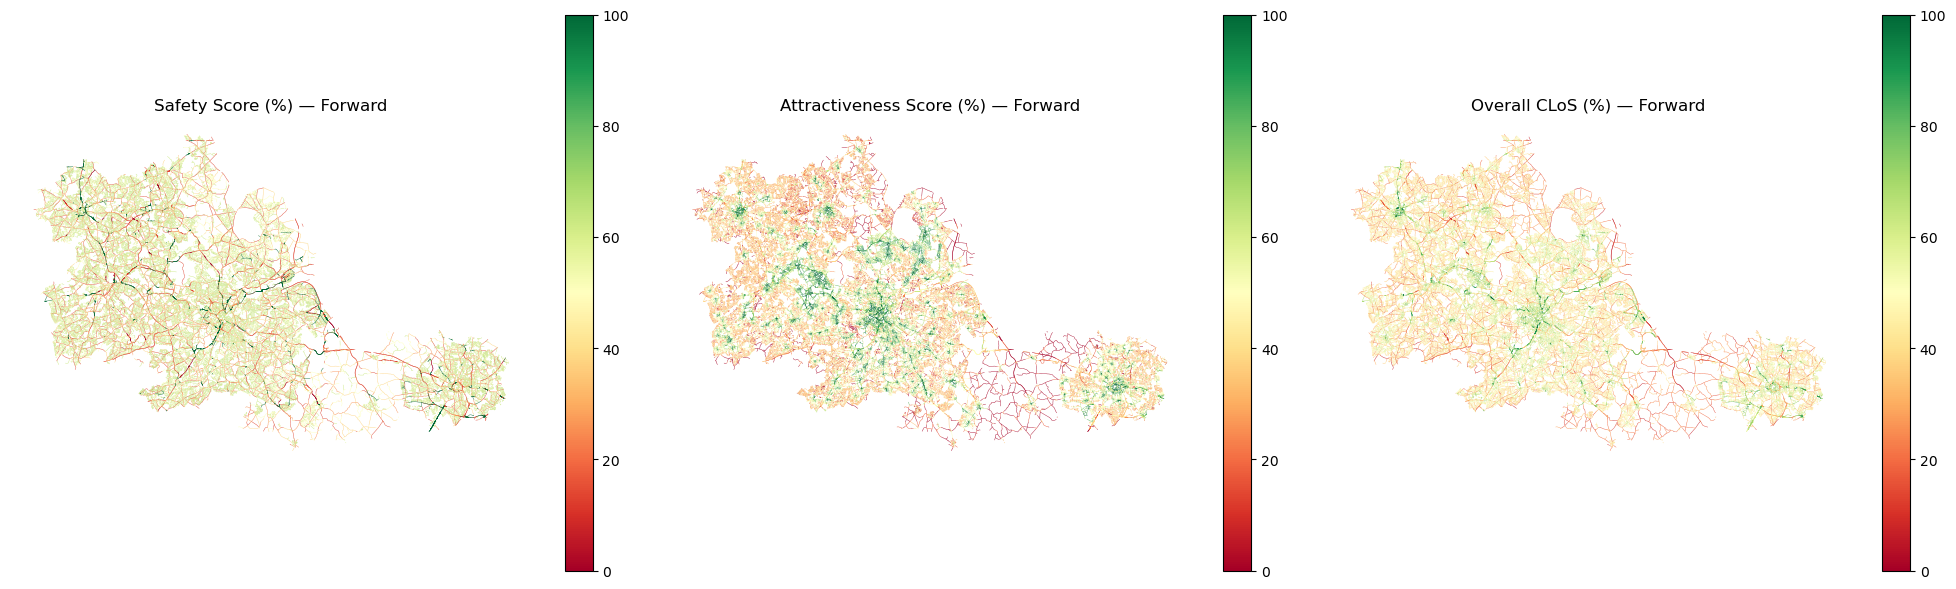

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, title in zip(axes,
    ['clos_safety_pct_fwd', 'clos_attract_pct_fwd', 'clos_overall_pct_fwd'],
    ['Safety Score (%) — Forward', 'Attractiveness Score (%) — Forward', 'Overall CLoS (%) — Forward']
):
    cycleable_roads_with_cl.plot(
        column=col, cmap='RdYlGn', legend=True,
        ax=ax, linewidth=0.3, missing_kwds={'color': 'lightgrey'}
    )
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

---
## 12. Export

In [132]:
# =============================================================================
# Export Scored Network
# =============================================================================

# --- Select columns for export ---
id_cols = ['osid', 'toid', 'geometry', 'geometry_length_m']

network_cols = [
    'description', 'roadclassification', 'routehierarchy',
    'roadclassificationnumber', 'name1_text',
    'startnode', 'endnode', 'directionality',
    'startgradeseparation', 'endgradeseparation',
]

attribute_cols = [
    'roadwidth_average', 'roadwidth_minimum',
    'est_v85_kph', 'est_v85_mph', 'indicativespeedlimit_mph',
    'aadt',
    'presenceofstreetlight_coverage',
]

facility_cols = [
    'facility_type_fwd', 'facility_type_bwd',
    'cl_type_fwd', 'cl_modalwidth_fwd', 'cl_minwidth_fwd', 'cl_side_fwd',
    'cl_type_bwd', 'cl_modalwidth_bwd', 'cl_minwidth_bwd', 'cl_side_bwd',
]

clos_safety_cols = [
    f'clos_{c}_{d}' for c in ['s10', 's11', 's12', 's15']
    for d in ['fwd', 'bwd']
] + [
    f'clos_{c}_critical_{d}' for c in ['s10', 's11', 's12', 's15']
    for d in ['fwd', 'bwd']
] + [
    f'clos_safety_pct_{d}' for d in ['fwd', 'bwd']
]

clos_attract_cols = [
    'clos_a3', 'clos_a21', 'clos_a22', 'clos_a25',
    'nearest_protected_m', 'poi_density', 'nearest_parking_m',
] + [
    f'clos_a19_{d}' for d in ['fwd', 'bwd']
] + [
    f'clos_attract_pct_{d}' for d in ['fwd', 'bwd']
]

jat_cols = [f'jat_score_{d}' for d in ['fwd', 'bwd']]

overall_cols = [f'clos_overall_pct_{d}' for d in ['fwd', 'bwd']]

# --- Assemble and filter ---
all_export_cols = (
    id_cols + network_cols + attribute_cols +
    facility_cols + clos_safety_cols + clos_attract_cols +
    jat_cols + overall_cols
)

# Only keep columns that actually exist
existing = [c for c in all_export_cols if c in cycleable_roads_with_cl.columns]
missing = [c for c in all_export_cols if c not in cycleable_roads_with_cl.columns]
if missing:
    print(f"Warning — columns not found (skipped): {missing}")

export = cycleable_roads_with_cl[existing].copy()

# --- Save ---
output_path = OUTPUT_DIR / "network_clos_scored.gpkg"
export.to_file(output_path, driver="GPKG")
print(f"Exported {len(export):,} links, {len(existing)} columns to {output_path}")
print(f"File size: {output_path.stat().st_size / 1e6:.1f} MB")

Exported 183,923 links, 64 columns to ../Data/Cleaned/network_clos_scored.gpkg
File size: 113.9 MB


In [140]:
# --- Web tool export (lightweight) ---
web_export_cols = [
    'osid', 'geometry', 'geometry_length_m',
    'startnode', 'endnode', 'directionality',
    'startgradeseparation', 'endgradeseparation',
    'name1_text', 'description', 'roadclassification',
    'facility_type_fwd', 'facility_type_bwd',
    'clos_overall_pct_fwd', 'clos_overall_pct_bwd',
    'clos_safety_pct_fwd', 'clos_safety_pct_bwd',
    'clos_attract_pct_fwd', 'clos_attract_pct_bwd',
    'jat_score_fwd', 'jat_score_bwd',
]

existing = [c for c in web_export_cols if c in cycleable_roads_with_cl.columns]
web_export = cycleable_roads_with_cl[existing].copy()

# Round
for col in web_export.select_dtypes(include='number').columns:
    web_export[col] = web_export[col].round(1)

web_path = OUTPUT_DIR / "network_clos_web.gpkg"
web_export.to_file(web_path, driver="GPKG")
print(f"Web export: {len(web_export):,} links, {len(existing)} columns")
print(f"File size: {web_path.stat().st_size / 1e6:.1f} MB")

Web export: 183,923 links, 21 columns
File size: 84.3 MB


In [142]:
web_4326.to_file(OUTPUT_DIR / "network_clos_web.geojson", driver="GeoJSON")
print(f"GeoJSON size: {(OUTPUT_DIR / 'network_clos_web.geojson').stat().st_size / 1e6:.1f} MB")

GeoJSON size: 176.5 MB


In [143]:
# Cycle Parking → GeoJSON (1,562 points, very small)
parking_4326 = parking.to_crs(4326)
parking_4326[['geometry']].to_file(
    OUTPUT_DIR / "cycle_parking.geojson", driver="GeoJSON"
)

# POI → GeoJSON (keep category for filtering)
pois_4326 = pois.to_crs(4326)
pois_export = pois_4326[['geometry', 'poi_category']].copy()
pois_export['poi_category'] = pois_export['poi_category'].astype(str)
pois_export.to_file(
    OUTPUT_DIR / "pois.geojson", driver="GeoJSON"
)

import os
print(f"Parking: {os.path.getsize(OUTPUT_DIR / 'cycle_parking.geojson') / 1e6:.1f} MB")
print(f"POIs: {os.path.getsize(OUTPUT_DIR / 'pois.geojson') / 1e6:.1f} MB")

Parking: 0.2 MB
POIs: 18.4 MB


In [148]:
# extracting the gradient information and length for the links
df = cycleable_roads_with_cl.copy()

length = pd.to_numeric(df['geometry_length_m'], errors='coerce')
elev_fwd = pd.to_numeric(df['elevationgain_indirection'], errors='coerce').fillna(0)
elev_bwd = pd.to_numeric(df['elevationgain_againstdirection'], errors='coerce').fillna(0)

# Clamp: ignore links < 5m (noise) and cap gradient at 20%
df['gradient_pct_fwd'] = np.where(length > 5, (elev_fwd / length * 100).clip(0, 20), 0).round(2)
df['gradient_pct_bwd'] = np.where(length > 5, (elev_bwd / length * 100).clip(0, 20), 0).round(2)

print(f"Gradient fwd: mean={df['gradient_pct_fwd'].mean():.2f}%, max={df['gradient_pct_fwd'].max():.1f}%")
print(f"Gradient bwd: mean={df['gradient_pct_bwd'].mean():.2f}%, max={df['gradient_pct_bwd'].max():.1f}%")

cycleable_roads_with_cl = df

Gradient fwd: mean=1.12%, max=20.0%
Gradient bwd: mean=1.11%, max=20.0%


In [149]:
import json, gzip

df = cycleable_roads_with_cl.copy()

all_nodes = set(df['startnode'].unique()) | set(df['endnode'].unique())
node_to_idx = {nid: i for i, nid in enumerate(all_nodes)}

node_coords = {}
for _, row in df.iterrows():
    coords = list(row.geometry.coords)
    sn, en = row['startnode'], row['endnode']
    if sn not in node_coords:
        node_coords[sn] = coords[0]
    if en not in node_coords:
        node_coords[en] = coords[-1]

from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

nodes_flat = []
for nid in sorted(node_to_idx, key=node_to_idx.get):
    x, y = node_coords[nid]
    lng, lat = transformer.transform(x, y)
    nodes_flat.extend([round(lng, 5), round(lat, 5)])

# Edges: [from, to, length_dm, overall*10, safety*10, attract*10, gradient*100]
edges = []
for _, row in df.iterrows():
    s = node_to_idx[row['startnode']]
    e = node_to_idx[row['endnode']]
    length = int(round(float(row['geometry_length_m'] or 0) * 10))
    
    fo = int(round(float(row.get('clos_overall_pct_fwd') or 0) * 10))
    bo = int(round(float(row.get('clos_overall_pct_bwd') or 0) * 10))
    fs = int(round(float(row.get('clos_safety_pct_fwd') or 0) * 10))
    bs = int(round(float(row.get('clos_safety_pct_bwd') or 0) * 10))
    fa = int(round(float(row.get('clos_attract_pct_fwd') or 0) * 10))
    ba = int(round(float(row.get('clos_attract_pct_bwd') or 0) * 10))
    fg = int(round(float(row.get('gradient_pct_fwd') or 0) * 100))
    bg = int(round(float(row.get('gradient_pct_bwd') or 0) * 100))
    
    directionality = row.get('directionality', 'Both Directions')
    
    if directionality in ['Both Directions', 'In Direction']:
        edges.append([s, e, length, fo, fs, fa, fg])
    if directionality in ['Both Directions', 'In Opposite Direction']:
        edges.append([e, s, length, bo, bs, ba, bg])

graph = {'n': nodes_flat, 'e': edges}

output_file = OUTPUT_DIR / "graph.json"
with open(output_file, 'w') as f:
    json.dump(graph, f, separators=(',', ':'))

output_gz = OUTPUT_DIR / "graph.json.gz"
with open(output_file, 'rb') as f_in:
    with gzip.open(output_gz, 'wb') as f_out:
        f_out.write(f_in.read())

print(f"Nodes: {len(nodes_flat)//2:,}")
print(f"Edges: {len(edges):,}")
print(f"JSON: {output_file.stat().st_size / 1e6:.1f} MB")
print(f"Gzip: {output_gz.stat().st_size / 1e6:.1f} MB")

Nodes: 159,568
Edges: 333,796
JSON: 14.0 MB
Gzip: 4.1 MB


In [150]:
import json, gzip

df = cycleable_roads_with_cl.copy()

all_nodes = set(df['startnode'].unique()) | set(df['endnode'].unique())
node_to_idx = {nid: i for i, nid in enumerate(all_nodes)}

node_coords = {}
for _, row in df.iterrows():
    coords = list(row.geometry.coords)
    sn, en = row['startnode'], row['endnode']
    if sn not in node_coords:
        node_coords[sn] = coords[0]
    if en not in node_coords:
        node_coords[en] = coords[-1]

from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

nodes_flat = []
for nid in sorted(node_to_idx, key=node_to_idx.get):
    x, y = node_coords[nid]
    lng, lat = transformer.transform(x, y)
    nodes_flat.extend([round(lng, 5), round(lat, 5)])

# Edge format: [from, to, length_dm, overall*10, safety*10, attract*10, gradient*100, a19*10, a3*10]
# a19: -1 if NaN (mixed traffic), a3: 0-20
edges = []
for _, row in df.iterrows():
    s = node_to_idx[row['startnode']]
    e = node_to_idx[row['endnode']]
    length = int(round(float(row['geometry_length_m'] or 0) * 10))
    
    fo = int(round(float(row.get('clos_overall_pct_fwd') or 0) * 10))
    bo = int(round(float(row.get('clos_overall_pct_bwd') or 0) * 10))
    fs = int(round(float(row.get('clos_safety_pct_fwd') or 0) * 10))
    bs = int(round(float(row.get('clos_safety_pct_bwd') or 0) * 10))
    fa = int(round(float(row.get('clos_attract_pct_fwd') or 0) * 10))
    ba = int(round(float(row.get('clos_attract_pct_bwd') or 0) * 10))
    fg = int(round(float(row.get('gradient_pct_fwd') or 0) * 100))
    bg = int(round(float(row.get('gradient_pct_bwd') or 0) * 100))
    
    # A19: NaN → -1 (not applicable), else score 0-2 → x10 for 0-20
    a19_fwd = row.get('clos_a19_fwd')
    a19_bwd = row.get('clos_a19_bwd')
    fa19 = int(round(float(a19_fwd) * 10)) if pd.notna(a19_fwd) else -1
    ba19 = int(round(float(a19_bwd) * 10)) if pd.notna(a19_bwd) else -1
    
    # A3: always scored, 0-2 → x10
    a3_val = row.get('clos_a3', 0)
    a3 = int(round(float(a3_val or 0) * 10))
    
    directionality = row.get('directionality', 'Both Directions')
    
    if directionality in ['Both Directions', 'In Direction']:
        edges.append([s, e, length, fo, fs, fa, fg, fa19, a3])
    if directionality in ['Both Directions', 'In Opposite Direction']:
        edges.append([e, s, length, bo, bs, ba, bg, ba19, a3])

graph = {'n': nodes_flat, 'e': edges}

output_file = OUTPUT_DIR / "graph.json"
with open(output_file, 'w') as f:
    json.dump(graph, f, separators=(',', ':'))

output_gz = OUTPUT_DIR / "graph.json.gz"
with open(output_file, 'rb') as f_in:
    with gzip.open(output_gz, 'wb') as f_out:
        f_out.write(f_in.read())

print(f"Nodes: {len(nodes_flat)//2:,}")
print(f"Edges: {len(edges):,}")
print(f"JSON: {output_file.stat().st_size / 1e6:.1f} MB")
print(f"Gzip: {output_gz.stat().st_size / 1e6:.1f} MB")

Nodes: 159,568
Edges: 333,796
JSON: 15.8 MB
Gzip: 4.3 MB
